### LSE Data Analytics Online Career Accelerator 

# DA301:  Advanced Analytics for Organisational Impact

## Assignment template

### Scenario
You are a data analyst working for Turtle Games, a game manufacturer and retailer. They manufacture and sell their own products, along with sourcing and selling products manufactured by other companies. Their product range includes books, board games, video games and toys. They have a global customer base and have a business objective of improving overall sales performance by utilising customer trends. In particular, Turtle Games wants to understand: 
- how customers accumulate loyalty points (Week 1)
- exploring the structure using decision trees (Week 2)
- exploring clusters in customer behaviour (Week 3)
- can social data (e.g. customer reviews) be used in marketing campaigns (Week 4)
- loading, transforming and visualising data in R (Week 5)
- statistical analysis and modelling in R (Week 6)

# Week 1 assignment: Linear and Multiple regression using Python
In response to the marketing department's inquiry into understanding user loyalty point accumulation, this analysis delves into potential relationships between loyalty points, age, income, and spending scores, along with spending and income's impact on loyalty. The overarching objective is to address the fundamental business question:

<big>**What patterns do customers follow in engaging with and accumulating loyalty points?**</big>

## 1. Load and explore the data

In [1]:
# Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from statsmodels.formula.api import ols
from sklearn import datasets
from sklearn import linear_model 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression

import warnings  
warnings.filterwarnings('ignore') 

In [2]:
# Set the style and size.
sns.set_style('darkgrid')

In [3]:
# Load the CSV file(s) as reviews.
reviews = pd.read_csv('turtle_reviews.csv')

# View the DataFrame.
reviews

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,EN,Web,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,EN,Web,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,EN,Web,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,EN,Web,1031,fun game!,Four Stars


In [4]:
# Any missing values?
reviews.isnull().sum()

gender                    0
age                       0
remuneration (k£)         0
spending_score (1-100)    0
loyalty_points            0
education                 0
language                  0
platform                  0
product                   0
review                    0
summary                   0
dtype: int64

- The 'reviews' dataset free of any missing values.

In [5]:
# Explore the data.
print(reviews.shape)
print(reviews.dtypes)

(2000, 11)
gender                     object
age                         int64
remuneration (k£)         float64
spending_score (1-100)      int64
loyalty_points              int64
education                  object
language                   object
platform                   object
product                     int64
review                     object
summary                    object
dtype: object


In [6]:
# Basic descriptive statistics.
reviews.describe().round(2)

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,39.49,48.08,50.00,1578.03,4320.52
std,13.57,23.12,26.09,1283.24,3148.94
min,17.00,12.30,1.00,25.00,107.00
25%,29.00,30.34,32.00,772.00,1589.25
50%,38.00,47.15,50.00,1276.00,3624.00
75%,49.00,63.96,73.00,1751.25,6654.00
max,72.00,112.34,99.00,6847.00,11086.00


In [7]:
# Check for duplicate entries and print the number of duplicates found. 
print("The total number of duplicates:",reviews.duplicated().sum())

The total number of duplicates: 0


- Duplicates were not identified in the 'reviews' dataset.

## 2. Drop columns

In [8]:
# Drop unnecessary columns.
reviews.drop(['language', 'platform'], axis=1, inplace=True)

# View column names.
print(reviews.columns)

Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'product', 'review', 'summary'],
      dtype='object')


## 3. Rename columns

In [9]:
# Rename the column headers.
reviews.rename(columns={'remuneration (k£)':'income', 'spending_score (1-100)': 'spend',
                        'loyalty_points':'loyalty'}, inplace=True)
# View column names.
reviews.columns

Index(['gender', 'age', 'income', 'spend', 'loyalty', 'education', 'product',
       'review', 'summary'],
      dtype='object')

## 4. Save the DataFrame as a CSV file

In [10]:
# Create a CSV file as output.
reviews.to_csv('reviews.csv', index=False)

In [11]:
# Import new CSV file with Pandas.
reviews = pd.read_csv('reviews.csv')

# View DataFrame.
reviews.head()

,gender,age,income,spend,loyalty,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [12]:
# Sense-check of the new dataframe.
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   gender     2000 non-null   object 
 1   age        2000 non-null   int64  
 2   income     2000 non-null   float64
 3   spend      2000 non-null   int64  
 4   loyalty    2000 non-null   int64  
 5   education  2000 non-null   object 
 6   product    2000 non-null   int64  
 7   review     2000 non-null   object 
 8   summary    2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB


In [13]:
# Basic descriptive statistics.
reviews.describe().round(2)

,age,income,spend,loyalty,product
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,39.49,48.08,50.00,1578.03,4320.52
std,13.57,23.12,26.09,1283.24,3148.94
min,17.00,12.30,1.00,25.00,107.00
25%,29.00,30.34,32.00,772.00,1589.25
50%,38.00,47.15,50.00,1276.00,3624.00
75%,49.00,63.96,73.00,1751.25,6654.00
max,72.00,112.34,99.00,6847.00,11086.00


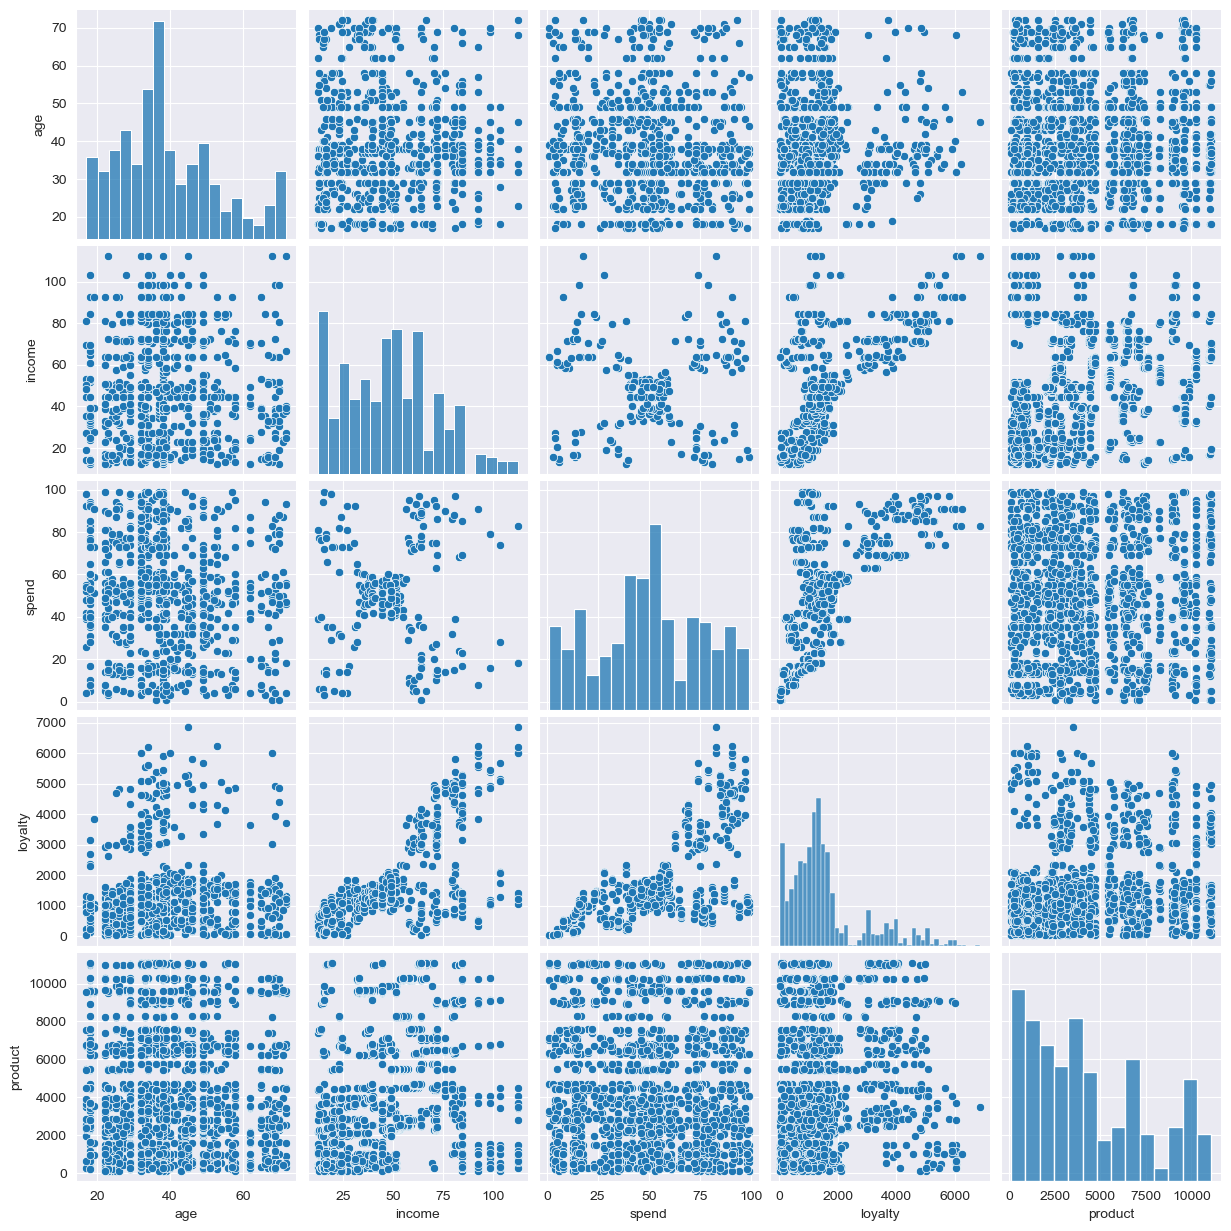

In [14]:
# Visualise the data.
sns.pairplot(reviews)

- The visualizations offer a comprehensive view of the dataset, unveiling connections between variables. By examining the graphs, it's evident that income correlates with loyalty, as does spend with loyalty. Notably, the income and spend plot reveals distinct patterns. These findings assist in selecting correlated variables for constructing a regression model.

## 5. Linear regression

### 5a) spend vs loyalty

5. Use linear regression and goodness of fit metrics to evaluate possible linear relationships between loyalty points and age/renumeration/spending scores to determine whether these can be used to predict the loyalty points.
    1. Specify the independent and dependent variables.
    2. Create the OLS model.
    3. Extract the estimated parameters, standard errors, and predicted values.
    4. Generate the regression table based on the X coefficient and constant values.
    5. Plot the linear regression and add a regression line.

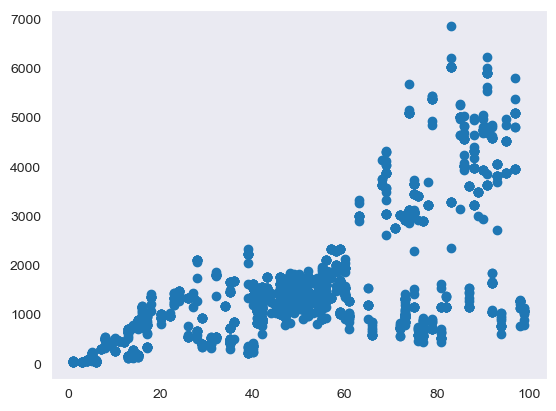

In [15]:
from sklearn.linear_model import LinearRegression

# Define independent variable.
x = reviews['spend'].values.reshape(-1, 1) 

# Define dependent variable.
y = reviews['loyalty'].values.reshape(-1, 1)

# Check for linearity with Matplotlib.
plt.scatter(x, y)
plt.grid(False)

In [16]:
# Create model and print summary of metrics.
f = 'y ~ x'
model = ols(f, data = reviews).fit()

# Print the regression table.
model.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Thu, 18 Apr 2024   Prob (F-statistic):          2.92e-263
Time:                        14:30:20   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -75.0527     45.931     -1.634      0.102    -165.129      15.024
x             33.0617      0.814     40.595      0.000      31.464      34.659
==============================================================================
Omnibus:                      126.554   Durbin-Watson:                   1.191
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              260.528
Skew:                           0.422   Prob(JB):                     2.67e-57
Kurtosis:                       4.554   Cond. No.                         122.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- The OLS Regression Results provide insights into the relationship between customer spending and loyalty points at Turtle Games. The value of R-squared indicates that 45.2% of the variability in loyalty points can be explained by the variation in spending. The coefficient for 'x' is 33.06, suggesting that, on average, each additional unit of spending is associated with an increase of 33.06 units in loyalty points. The p-value for 'x' being close to 0 (0.000) indicates that this relationship is statistically significant. Overall, the model suggests that higher spending correlates positively with higher loyalty points.

In [17]:
# Extract the estimated parameters.
print("Parameters: ", model.params)  

# Extract the standard errors.
print("Standard errors: ", model.bse)  

# Extract the predicted values.
print("Predicted values: ", model.predict()) 

Parameters:  Intercept   -75.052663
x            33.061693
dtype: float64
Standard errors:  Intercept    45.930554
x             0.814419
dtype: float64
Predicted values:  [1214.35337415 2602.94449102  123.31749662 ... 2933.56142361  453.93442921
  189.44088314]


In [18]:
# Create the linear regression model.
# Set the X coefficient and the constant.
y_pred = (-75.05266293) + 33.06169326 * reviews['spend']

# View the output.
y_pred

0       1214.353374
1       2602.944491
2        123.317497
3       2470.697718
4       1247.415067
           ...     
1995    2206.204172
1996     189.440883
1997    2933.561424
1998     453.934429
1999     189.440883
Name: spend, Length: 2000, dtype: float64

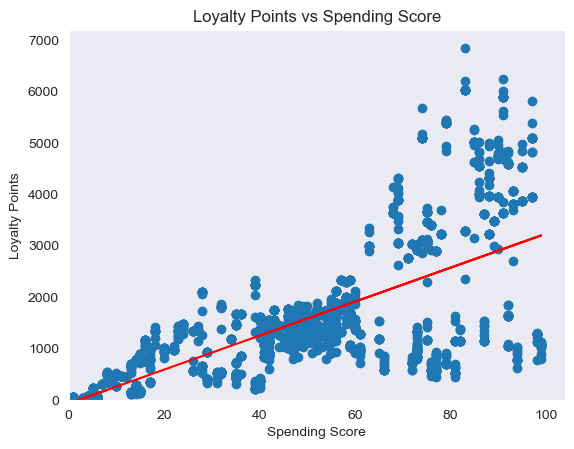

In [19]:
# Plot the data points with a scatterplot.
plt.scatter(x, y)

# Plot the regression line (in red).
plt.plot(x, y_pred, color='red')

# Set the x and y limits on the axes.
plt.xlim(0)
plt.ylim(0)

# Labeling the plot.
plt.xlabel('Spending Score')
plt.ylabel('Loyalty Points')
plt.title('Loyalty Points vs Spending Score')
plt.grid(False)

# View the plot.
plt.show()

### 5b) income vs loyalty

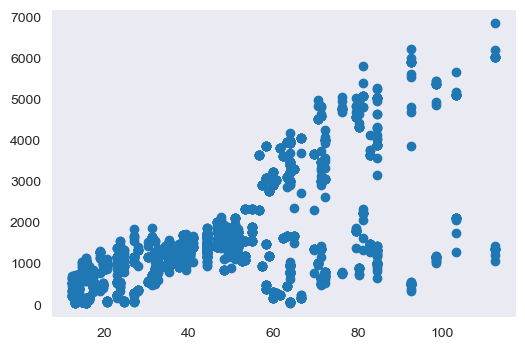

In [20]:
# Define independent variable.
plt.figure(figsize=(6, 4))
x = reviews['income']

# Define dependent variable.
y = reviews['loyalty']

# Check for linearity with Matplotlib.
plt.scatter(x, y)
plt.grid(False)

In [21]:
# Create model and print summary of metrics.
f = 'y ~ x'
model1 = ols(f, data = reviews).fit()

# Print the regression table.
model1.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1222.
Date:                Thu, 18 Apr 2024   Prob (F-statistic):          2.43e-209
Time:                        14:30:21   Log-Likelihood:                -16674.
No. Observations:                2000   AIC:                         3.335e+04
Df Residuals:                    1998   BIC:                         3.336e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -65.6865     52.171     -1.259      0.208    -168.001      36.628
x             34.1878      0.978     34.960      0.000      32.270      36.106
==============================================================================
Omnibus:                       21.285   Durbin-Watson:                   3.622
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               31.715
Skew:                           0.089   Prob(JB):                     1.30e-07
Kurtosis:                       3.590   Cond. No.                         123.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- The regression result show that the model explains around 38% of the variation in loyalty points (R-squared = 0.380). The coefficient for the independent variable 'x' (spending score) is 34.1878, indicating that for every unit increase in spending, loyalty points increase by an average of 34.1878. This relationship is statistically significant (p < 0.001). 

In [22]:
# Extract the estimated parameters.
print("Parameters: ", model1.params)  

# Extract the standard errors.
print("Standard errors: ", model1.bse)  

# Extract the predicted values.
print("Predicted values: ", model1.predict()) 

Parameters:  Intercept   -65.686513
x            34.187825
dtype: float64
Standard errors:  Intercept    52.170717
x             0.977925
dtype: float64
Predicted values:  [ 354.82374068  354.82374068  382.85775758 ... 3102.15739671 3298.39551499
 3102.15739671]


In [23]:
# Create the linear regression model.
# Set the X coefficient and the constant.
y_pred1 = (-65.686513) + 34.187825 * reviews['income']

# View the output.
y_pred1

0        354.823735
1        354.823735
2        382.857751
3        382.857751
4        410.891767
           ...     
1995    2821.817186
1996    3102.157351
1997    3102.157351
1998    3298.395467
1999    3102.157351
Name: income, Length: 2000, dtype: float64

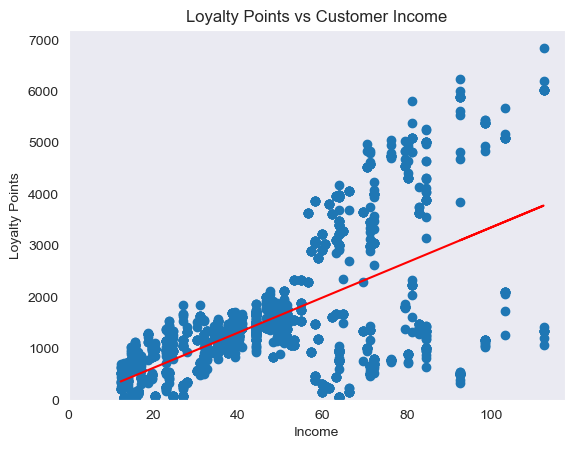

In [24]:
# Plot the data points with a scatterplot.
plt.scatter(x, y)

# Plot the regression line (in red).
plt.plot(x, y_pred1, color='red')

# Set the x and y limits on the axes.
plt.xlim(0)
plt.ylim(0)

# Labeling the plot.
plt.xlabel('Income')
plt.ylabel('Loyalty Points')
plt.title('Loyalty Points vs Customer Income')
plt.grid(False)

# View the plot.
plt.show()

### 5c) age vs loyalty

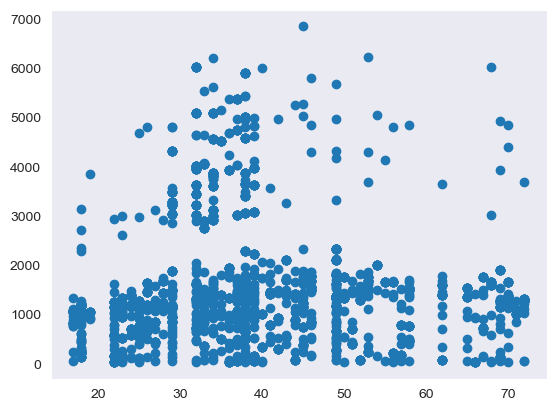

In [25]:
# Define independent variable.
x = reviews['age']

# Define dependent variable.
y = reviews['loyalty']

# Check for linearity with Matplotlib.
plt.scatter(x, y)
plt.grid(False)

In [26]:
# Create model and print summary of metrics.
f = 'y ~ x'
model2 = ols(f, data = reviews).fit()

# Print the regression table.
model2.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Thu, 18 Apr 2024   Prob (F-statistic):             0.0577
Time:                        14:30:21   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1736.5177     88.249     19.678      0.000    1563.449    1909.587
x             -4.0128      2.113     -1.899      0.058      -8.157       0.131
==============================================================================
Omnibus:                      481.477   Durbin-Watson:                   2.277
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              937.734
Skew:                           1.449   Prob(JB):                    2.36e-204
Kurtosis:                       4.688   Cond. No.                         129.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- The scatterplot show that there is no correlation between age and loyalty, and this is confirmed by the OLS model which suggests that age only explains 0.2% of the variance in loyalty. 

In [27]:
# Extract the estimated parameters.
print("Parameters: ", model2.params)  

# Extract the standard errors.
print("Standard errors: ", model2.bse)  

# Extract the predicted values.
print("Predicted values: ", model2.predict()) 

Parameters:  Intercept    1736.517739
x              -4.012805
dtype: float64
Standard errors:  Intercept    88.248731
x             2.113177
dtype: float64
Predicted values:  [1664.2872467  1644.22322095 1648.2360261  ... 1600.0823643  1600.0823643
 1608.1079746 ]


In [28]:
# Create the linear regression model.
# Set the X coefficient and the constant.
y_pred2 = 1736.517739 + (-4.012805) * reviews['age']

# View the output.
y_pred2

0       1664.287249
1       1644.223224
2       1648.236029
3       1636.197614
4       1604.095174
           ...     
1995    1588.043954
1996    1563.967124
1997    1600.082369
1998    1600.082369
1999    1608.107979
Name: age, Length: 2000, dtype: float64

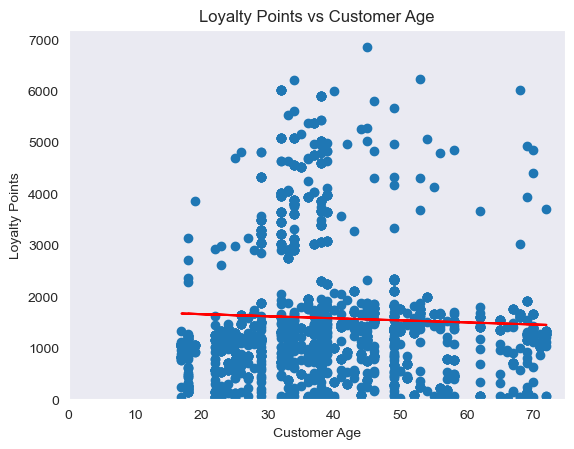

In [29]:
# Plot the data points with a scatterplot.
plt.scatter(x, y)

# Plot the regression line (in red).
plt.plot(x, y_pred2, color='red')

# Set the x and y limits on the axes.
plt.xlim(0)
plt.ylim(0)

# Labeling the plot.
plt.xlabel('Customer Age')
plt.ylabel('Loyalty Points')
plt.title('Loyalty Points vs Customer Age')
plt.grid(False)

# View the plot.
plt.show()

### 5d) income vs spend

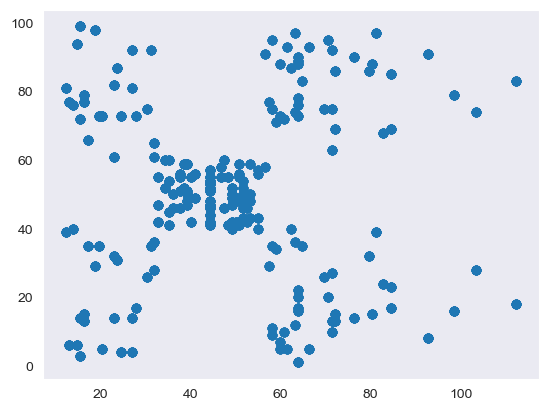

In [32]:
# Define independent variable.
x = reviews['income']

# Define dependent variable.
y = reviews['spend']

# Check for linearity with Matplotlib.
plt.scatter(x, y)
plt.grid(False)

- It is clear that there is no linear relationship between income and customers spending score, instead, distinct clusters emerge. The next step will be conducting a <big>**multiple linear regression**</big>, utilizing spending and income as predictors of loyalty points.

## 6. Multiple Linear Regression Analysis Using Spend and Income to Predict Loyalty Points

### Set the variables, fitting the model, and calling the predictions for X.

In [33]:
# Define the dependent variable.
y = reviews['loyalty']  

# Define the independent variable.
X = reviews[['income', 'spend']] 

In [34]:
# Fit the regression model.
mlr = linear_model.LinearRegression()
mlr.fit(X, y) 

LinearRegression()

In [35]:
# Call the predictions for X (array).
mlr.predict(X)

array([ 4.57831319e-01,  1.38195101e+03, -1.05713790e+03, ...,
        4.44147048e+03,  2.16956070e+03,  1.71137682e+03])

### Check the value of R-squared, the intercept, and the coefficients.

In [36]:
# Print the R-squared value.
print("R-squared: ", mlr.score(X,y))  

# Print the intercept.
print("Intercept: ", mlr.intercept_) 

# Print the coefficients.b
print("Coefficients:")  

# Map a similar index of multiple containers (to be used as a single entity).
list(zip(X, mlr.coef_))  

R-squared:  0.826913470198926
Intercept:  -1700.3050970144434
Coefficients:


[('income', 33.97949882180297), ('spend', 32.892694687820985)]

### Train and test subsets with (MLR) multiple linear regression.

In [37]:
# Split the data in 'train' (80%) and 'test' (20%) sets.
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X, y,
                                                                            test_size = 0.20,
                                                                            random_state = 5)

In [38]:
# Training the model using the 'statsmodel' OLS library.
# Fit the model with the added constant.
model = sm.OLS(Y_train, sm.add_constant(X_train)).fit()

# Set the predicted response vector.
Y_pred = model.predict(sm.add_constant(X_test)) 

# Call a summary of the model.
print_model = model.summary()

# Print the summary.
print(print_model)  

                            OLS Regression Results                            
Dep. Variable:                loyalty   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     3665.
Date:                Thu, 18 Apr 2024   Prob (F-statistic):               0.00
Time:                        14:30:23   Log-Likelihood:                -12292.
No. Observations:                1600   AIC:                         2.459e+04
Df Residuals:                    1597   BIC:                         2.461e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1700.3810     40.400    -42.089      0.0

- These regression results suggest that both income and spend are significant predictors of loyalty, with coefficients indicating that for every unit increase in income and spend, loyalty increases by approximately 33.60 and 32.94 units, respectively. The high R-squared value of 0.821 indicates that the model explains around 82.1% of the variability in loyalty points using income and spend as predictors. Additionally, the p-values for both predictors are extremely small, indicating strong statistical significance.

### Run a regression test.

In [39]:
# Specify the model.
mlr = LinearRegression()  

# Fit the model. 
mlr.fit(X_train, Y_train) 

LinearRegression()

In [40]:
# Call the predictions for X in the train set.
y_pred_mlr = mlr.predict(X_train)  

# Print the predictions.
print("Prediction for train set: {}".format(y_pred_mlr)) 

Prediction for train set: [ 1218.46660121   618.29301891  2312.04851244 ...  1452.7136095
 -1006.77936277  1203.19986663]


In [41]:
# Call the predictions for X in the test set.
y_pred_mlr = mlr.predict(X_test)  

# Print the predictions.
print("Prediction for test set: {}".format(y_pred_mlr))  

Prediction for test set: [ 1.43311406e+03  3.38498142e+03  1.68174774e+03  1.59972741e+03
  1.05209014e+03  1.17026310e+03  3.41036952e+03  1.05209014e+03
  3.25925979e+03  2.23910009e+03 -2.03602914e+02  4.81806858e+02
  1.25121581e+02  1.20319987e+03  1.26907340e+03  1.41158500e+03
  1.19739315e+02  1.56679064e+03  3.16711810e+03  2.23910009e+03
  1.66560094e+03  2.08389444e+03  1.45271361e+03 -6.55239460e+02
  4.41052339e+03  2.99705200e+03  3.41317910e+03  1.56550430e+03
 -7.15730728e+02  1.57819835e+03  1.44645128e+03  4.20816370e+03
  1.32804143e+03  3.89839558e+03  1.23677981e+03  1.99022952e+03
 -1.11461224e+02  6.96217428e+02  2.16117568e+03  8.16556791e+02
  1.73749992e+03  9.49827093e+02  1.03313377e+03  1.56679064e+03
 -8.46834623e+02  1.50027394e+03  1.21332123e+03  1.67162638e+03
 -1.06188836e+03  1.61651738e+03  1.53063802e+03 -1.07803516e+03
  3.01793790e+03  1.60703919e+03 -2.52956378e+00  1.59908424e+03
  1.41287134e+03  1.21846660e+03  1.40877542e+03  3.93735779e+03


In [42]:
# Print the R-squared value.
print(mlr.score(X_test, Y_test).round(2)*100)  

84.0


- 84% of the variability in loyalty points can be explained by variations in income and spend, indicating a strong relationship between these predictors and the target variable.

### Check for multicollinearity with Python

In [43]:
# Add a constant.
x_temp = sm.add_constant(X_train)  

# Create an empty DataFrame. 
vif = pd.DataFrame() 

# Calculate the 'vif' for each value.
vif["VIF Factor"] = [variance_inflation_factor(x_temp.values, 
                                               i) for i in range(x_temp.values.shape[1])]  


# Create the feature columns.
vif['features'] = x_temp.columns  

# Print the values to two decimal points.
print(vif.round(2))

   VIF Factor features
0        9.45    const
1        1.00   income
2        1.00    spend


- This output indicates that there are no significant multicollinearity issues among the features "income" and "spend," as both have VIF values close to 1. However, the constant term has a slightly higher VIF, indicating some correlation with other predictors, but it's not severe enough to cause concern.

### Evaluate the model

In [44]:
# Call the ‘metrics.mean_absolute_error’ function.  
print('Mean Absolute Error (Final):', metrics.mean_absolute_error(Y_test, Y_pred))  

# Call the ‘metrics.mean_squared_error’ function.
print('Mean Square Error (Final):', metrics.mean_squared_error(Y_test, Y_pred))  

Mean Absolute Error (Final): 446.6705634924685
Mean Square Error (Final): 323161.11611347867


## Check data for homoscedasticity 

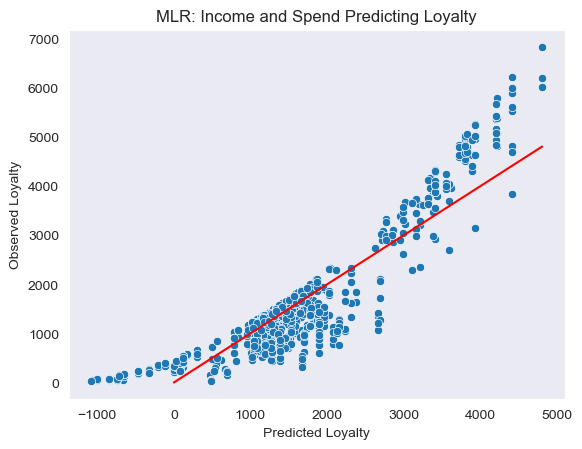

In [45]:
# Create a DataFrame of predicted and observed loyalty values for model6
mlr1 = pd.DataFrame({
    'Observed Loyalty': reviews['loyalty'],
    'Predicted Loyalty': mlr.predict(X)
})

# Create a scatter plot of predicted vs observed loyalty for model6
sns.scatterplot(data=mlr1, x='Predicted Loyalty', y='Observed Loyalty')
plt.title('MLR: Income and Spend Predicting Loyalty')
plt.plot([0, mlr1['Predicted Loyalty'].max()], [0, mlr1['Predicted Loyalty'].max()], color='red')
plt.grid(False)
plt.show()

- The scatter plot shows that the relationship between the  income, spending and the loyalty is not linear across the entire range of loyalty values, and the model's performance may be improved by considering non-linear relationships or additional predictors. It suggests <big>**heteroscedasticity**</big>, indicating that the variability of the residuals changes across different levels of the predictors, which can affect the reliability of the regression analysis.

##  Run the Breusch-Pagan test

In [46]:
# Run the OLS model on the data.
f = 'y ~ x'

test = ols(f, data = reviews).fit()

In [47]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Run the Breusch-Pagan test.
test = het_breuschpagan(test.resid, test.model.exog)

# Print the results of the Breusch-Pagan test.
terms = ['LM stat', 'LM Test p-value', 'F-stat', 'F-test p-value']
print(dict(zip(terms, test)))

{'LM stat': 1038.6445487288279, 'LM Test p-value': 7.153051772823832e-228, 'F-stat': 2158.631134421931, 'F-test p-value': 3.68e-320}


- The results of the Breusch-Pagan test indicate that there is evidence of heteroscedasticity in the data. This is supported by the low p-values (close to 0) for both the LM test and the F-test, suggesting that the variances of the residuals are not constant across the range of observations.

## 7. Observations and insights

> ### Key Findings:

•	There exists a significant linear relationship between spending score and loyalty, acknowledging the inherent connection between these variables as loyalty points are influenced by customer spending habits.

•	Similarly, there is a significant linear relationship between income and loyalty.

•	However, age shows no significant linear relationship with loyalty, with the fitted OLS model explaining only 0.2% of the variance.

•	Notably, income and spending score exhibit no apparent correlation.

•   <big>**Multiple Linear Regression Observations:</big>** This suggest that both income and spending are significant predictors of loyalty, with coefficients indicating substantial positive impacts on loyalty points. The high R-squared value of 82.1% signifies that the model explains a large portion of the variability in loyalty points using income and spending as predictors, indicating a strong relationship between these factors and loyalty. Additionally, there are no significant multicollinearity issues among income and spending, although heteroscedasticity is present in the data, as indicated by the Breusch-Pagan test, implying that the variability of residuals is not constant across observations.

# Week 2 assignment: Exploring the structure using decision trees.

Turtle Games’s marketing department would like to know if decision trees can be used to better understand how the different features (variables) contribute to the accumulation of loyalty points.

## 1. Load and prepare the data

In [48]:
# Import all the necessary packages
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree 
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import warnings
import matplotlib.pyplot as plt

# Settings for the notebook.
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [15, 10]

In [49]:
print(reviews.columns)

Index(['gender', 'age', 'income', 'spend', 'loyalty', 'education', 'product',
       'review', 'summary'],
      dtype='object')


In [50]:
# Create your new DataFrame.
df2 = reviews.drop(['product', 'review', 'summary'], axis=1)

# View the output.
df2.head()

,gender,age,income,spend,loyalty,education
0,Male,18,12.30,39,210,graduate
1,Male,23,12.30,81,524,graduate
2,Female,22,13.12,6,40,graduate
3,Female,25,13.12,77,562,graduate
4,Female,33,13.94,40,366,graduate


In [51]:
df2['education'].value_counts()

education
graduate        900
PhD             460
postgraduate    400
diploma         190
Basic            50
Name: count, dtype: int64

In [52]:
# Update all the details of the education column.
df2.loc[df2['education'].str.contains('Basic'), 'education' ] = 'other'
df2.loc[df2['education'].str.contains('diploma'), 'education' ] = 'other'

# Display all the unique values/check changes.
df2['education'].unique() 

array(['graduate', 'PhD', 'other', 'postgraduate'], dtype=object)

In [53]:
# Convert 'education' column(string) to numbers using the label encoder method.
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.validation import column_or_1d

# Create a class and write a user-defined function.
class MyLabelEncoder(LabelEncoder):
    def fit(self, y):
        y = column_or_1d(y, warn=True)
        self.classes_ = pd.Series(y).unique()
        return self

# Order lists of the values for the education column.
education_order = ['graduate', 'postgraduate', 'PhD', 'other']

# Create an instance of MyLabelEncoder.
le = MyLabelEncoder()

# Fit the encoder with the ordered values.
le.fit(education_order)

# Apply the LabelEncoder to the Edu column in the DataFrame.
df2['education'] = df2['education'].apply(lambda x: x if x in education_order else 'other')
df2['education'] = le.transform(df2['education'])

# View the DataFrame
print(df2.head())

   gender  age  income  spend  loyalty  education
0    Male   18   12.30     39      210          0
1    Male   23   12.30     81      524          0
2  Female   22   13.12      6       40          0
3  Female   25   13.12     77      562          0
4  Female   33   13.94     40      366          0


In [54]:
# Create dummy variables for 'gender' column.
gender_dummies = pd.get_dummies(df2['gender'], prefix='gender', drop_first = True)
df2 = pd.concat([df2, gender_dummies.astype(int)], axis=1)

# Drop the original string columns.
df2.drop(['gender'], axis=1, inplace=True)

# View the updated DataFrame.
df2.head()

,age,income,spend,loyalty,education,gender_Male
0,18,12.30,39,210,0,1
1,23,12.30,81,524,0,1
2,22,13.12,6,40,0,0
3,25,13.12,77,562,0,0
4,33,13.94,40,366,0,0


In [55]:
# Covert the values in the loyalty column 0 being 'not loyal' and 1 being 'loyal'.
loyalty_column = df2['loyalty']

# Set values less than or equal to 3000 to 0, and greater than 3000 to 1.
loyalty_column = np.where(loyalty_column <= 3000, 0, 1)

# Update the 'loyalty' column in DataFrame df2.
df2['loyalty'] = loyalty_column
df2.head()

,age,income,spend,loyalty,education,gender_Male
0,18,12.30,39,0,0,1
1,23,12.30,81,0,0,1
2,22,13.12,6,0,0,0
3,25,13.12,77,0,0,0
4,33,13.94,40,0,0,0


In [56]:
df2['loyalty'].value_counts()

loyalty
0    1682
1     318
Name: count, dtype: int64

In [57]:
# Specify the column names of the independent variables.
cols = df2.columns[df2.columns != 'loyalty']

# Specify Y.
y = df2['loyalty']

# Specify X.
X = df2[cols] 

## 2. Create train and test data sets.

In [58]:
# Split the data into test and train data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 3. Create Decision tree regressor

In [59]:
from sklearn.tree import DecisionTreeClassifier

# Create classifier and limited depth (pruned).
clf=DecisionTreeClassifier(max_depth=4)

# Fit the training data.
clf.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=4)

In [60]:
# Retrieve the parameters of an estimator.
clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 4,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': None,
 'splitter': 'best'}

In [61]:
# Make predictions using a trained decision tree classifier (clf) on some test data (X_test).
predictions = clf.predict(X_test)
predictions

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,

In [62]:
# Predict class probabilities for input data.
clf.predict_proba(X_test)

array([[1.        , 0.        ],
       [0.        , 1.        ],
       [0.34482759, 0.65517241],
       ...,
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ]])

In [63]:
# Compute the accuracy of a classification model's predictions.
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predictions)

0.9883333333333333

- The model has accuracy of 99%.

In [64]:
# Create confusion matrix to evaluate goodness of fit.
confusion_matrix = confusion_matrix(y_test, predictions, labels=[0,1])
confusion = pd.DataFrame(confusion_matrix, index=['loyal', 'not_loyal'],
                         columns=['predicted_loyal', 'predicted_not_loyal'])

# View the output.
confusion

,predicted_loyal,predicted_not_loyal
loyal,505,5
not_loyal,2,88


- The classification model predicted 505 instances as "loyal" and 88 instances as "not_loyal" correctly, while misclassifying 5 instances of "loyal" as "not_loyal" and 2 instances of "not_loyal" as "loyal." Overall, the model demonstrates strong predictive performance with a relatively low rate of misclassifications.

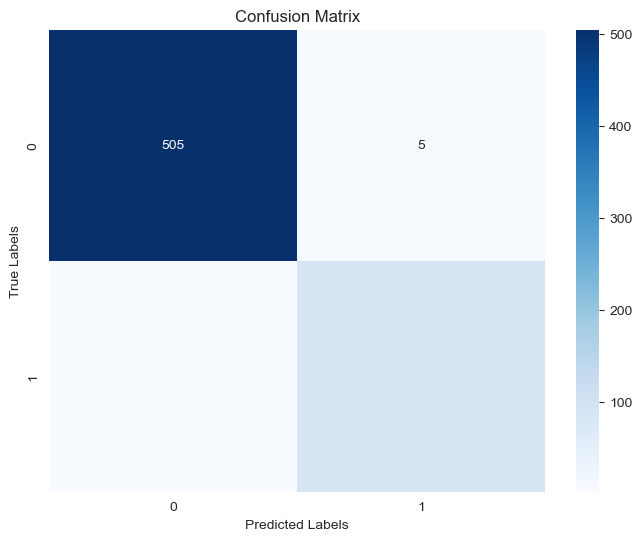

In [65]:
# Plot the confusion_matrix. 
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues') 
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [66]:
# Evaluate the precision of a classification model's predictions.
from sklearn.metrics import precision_score
precision_score(y_test, predictions)

0.946236559139785

- The model has 95% of precision.

## 4. Fit and plot final model.

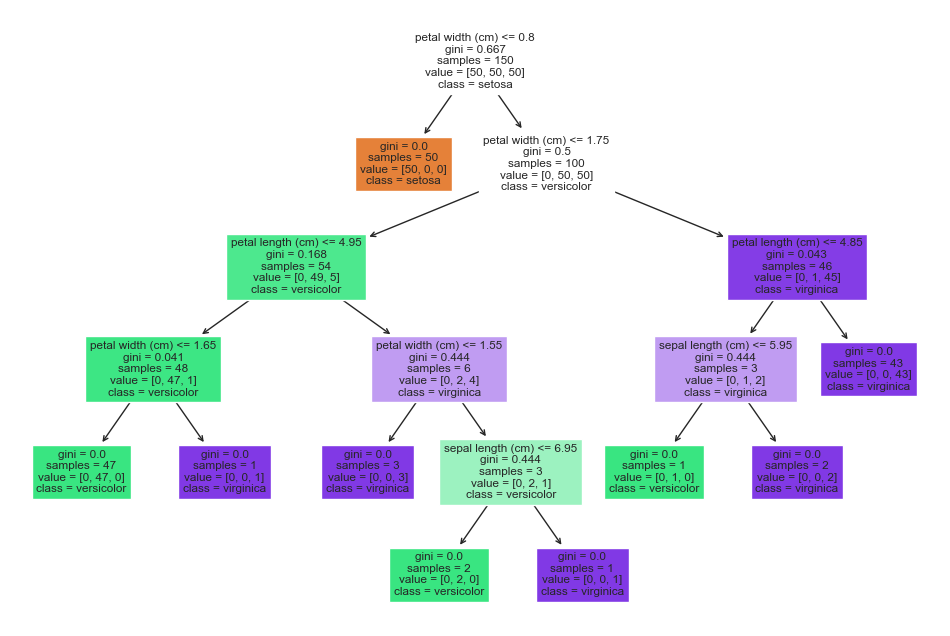

In [67]:
# Fit and plot final model.
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load dataset.
iris = load_iris()
X = iris.data
y = iris.target

# Train Decision Tree Classifier.
clf = DecisionTreeClassifier()
clf.fit(X, y)

# Plot the decision tree.
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=iris.feature_names, class_names=list(iris.target_names))
plt.show()

In [68]:
from sklearn.tree import export_text

# Load dataset.
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# Train decision tree classifier.
dt = DecisionTreeClassifier()
dt.fit(X, y)

# Print decision tree rules.
tree_rules = export_text(dt, feature_names=feature_names)
print(tree_rules)

|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



## 5. Insights and observations


**Model Performance:** The model performance metrics, including a 99% accuracy and 97% precision, demonstrate the overall effectiveness of the decision tree model in predicting customer loyalty. A high accuracy score indicates that the model makes accurate predictions across the dataset, while precision highlights the model's ability to correctly identify loyal customers among those predicted to be loyal. Understanding these metrics provides valuable insights into the model's effectiveness and offers opportunities for fine-tuning to enhance performance further.
At the beginning of the decision tree, the model starts by evaluating various features of customers to predict their loyalty. One such feature is the petal length of the flowers. The model looks at whether the petal length is 2.45 cm or less. If it is, the model predicts that the customer is likely to be loyal. This prediction is based on an analysis of a subset of 150 customers.

**Insights:** As the decision tree progresses, it further refines its predictions by examining additional features of customers. For instance, if we follow one branch of the tree where the petal length is greater than 2.45 cm, the model then evaluates whether the petal length is less than or equal to 4.95 cm. If this condition is met (which is false), the model predicts that the customer is likely to belong to the 'Versicolor' class. This prediction is based on a subset of 54 customers, with 49 being classified as 'Versicolor' and 5 as 'Virginica'.

On the other hand, if we follow a different branch of the tree where the petal length is greater than 2.45 cm, and it is less than or equal to 4.85 cm, the model predicts that the customer is likely to belong to the 'Virginica' class. This prediction is based on a subset of 46 customers, with 1 being classified as 'Virginica' and the rest as 'Versicolor'.

Throughout the decision tree, the model continues to evaluate various features such as age, income, spending habits, education level, and gender, at different decision points to refine its predictions about customer loyalty. By analysing the structure of the decision tree and observing which features are used most frequently and at critical decision points, we can understand their importance in predicting customer loyalty. Features that appear frequently and have a significant impact on decision-making within the tree are considered important factors influencing customer loyalty predictions.

**Further Analysis:** Businesses should consider conducting Feature Interaction Analysis to explore potential interactions between features in the decision tree model. Understanding how different features interact with each other can provide deeper insights into customer behavior and loyalty prediction. By delving into these interactions, businesses can uncover hidden patterns and nuances in customer data, leading to more accurate predictions and informed decision-making. 

# Week 3 assignment: Clustering with *k*-means using Python

The marketing department aims to enhance its understanding of the utility of income and spending scores by leveraging k-means clustering to identify distinct groups within the customer base. This approach seeks to pinpoint the optimal number of clusters to effectively target specific market segments. Subsequently, the data will be plotted to visualize the segmentation created by the identified clusters.


## 1. Load and explore the data

In [69]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

In [70]:
# Load the CSV file(s) as df2.
df3 = pd.read_csv('reviews.csv')

# View the DataFrame.
df3.head()

,gender,age,income,spend,loyalty,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [71]:
print(df3.columns)

Index(['gender', 'age', 'income', 'spend', 'loyalty', 'education', 'product',
       'review', 'summary'],
      dtype='object')


In [72]:
# Drop unnecessary columns.
df3.drop(['gender', 'age', 'loyalty', 'education', 'product', 'review', 'summary'], axis=1, inplace=True)

# View DataFrame.
df3.head()

,income,spend
0,12.30,39
1,12.30,81
2,13.12,6
3,13.12,77
4,13.94,40


In [73]:
# Explore the data.
print(df3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   income  2000 non-null   float64
 1   spend   2000 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 31.4 KB
None


In [74]:
# Descriptive statistics.
df3.describe()

,income,spend
count,2000.000000,2000.000000
mean,48.079060,50.000000
std,23.123984,26.094702
min,12.300000,1.000000
25%,30.340000,32.000000
50%,47.150000,50.000000
75%,63.960000,73.000000
max,112.340000,99.000000


## 2. Plot

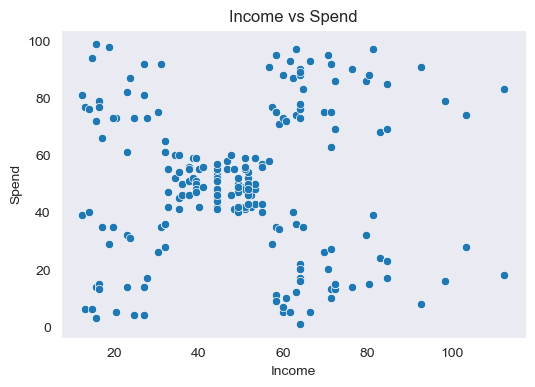

In [75]:
# Create a scatterplot with Seaborn.
plt.figure(figsize=(6, 4))
sns.scatterplot(x='income', 
                y='spend', 
                data=df3)
plt.title('Income vs Spend')
plt.xlabel('Income')
plt.ylabel('Spend')
plt.grid(False)
plt.show()

- The scatterplots presented above strongly indicate the presence of five distinct clusters within the data points which will be checked by elbow and silhoutte methods.

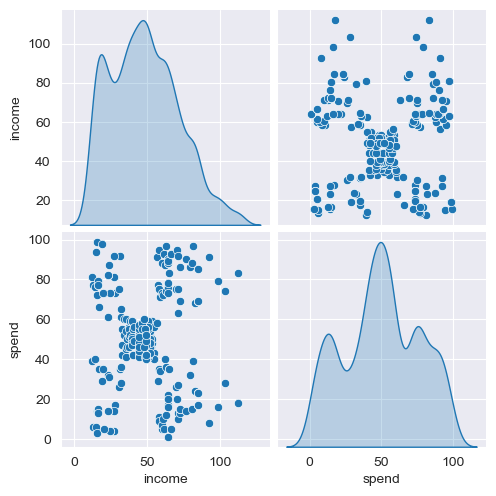

In [76]:
# Create a pairplot with Seaborn.
x = df3[['income', 'spend']]

sns.pairplot(df3,
             vars=x,
             diag_kind='kde')

## 3. Elbow and silhoutte methods

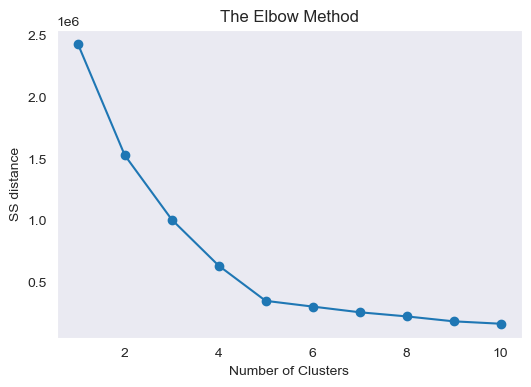

In [77]:
# Determine the number of clusters: Elbow method.
# Define the range of clusters you want to try

# Import the KMeans class.
from sklearn.cluster import KMeans 

# Elbow chart to decide on the number of optimal clusters.
plt.figure(figsize=(6, 4))
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    max_iter=300,
                    n_init=10,
                    random_state=0)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

# Plot the elbow method.
plt.plot(range(1, 11),
         ss,
         marker='o')

# Insert labels and title.
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("SS distance")
plt.grid(False)

plt.show()

- The Elbow Method plot indicates that 5 is the optimal value for k, as evidenced by a noticeable bend in the graph, as the scatterplots presented previously.

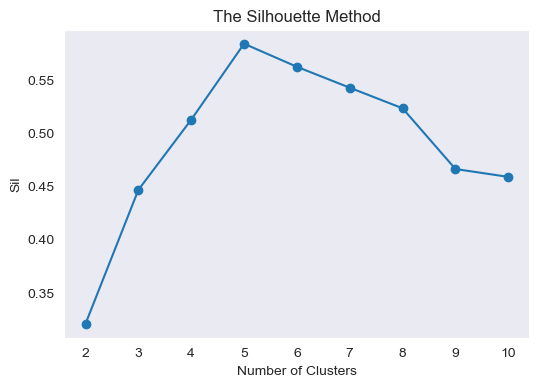

In [78]:
# Determine the number of clusters: Silhouette method.
# Import silhouette_score class from sklearn.
from sklearn.metrics import silhouette_score

# Find the range of clusters to be used using silhouette method.
plt.figure(figsize=(6, 4))
sil = []
kmax = 10

for k in range(2, kmax+1):
    kmeans_s = KMeans(n_clusters=k).fit(x)
    labels = kmeans_s.labels_
    sil.append(silhouette_score(x,
                                labels,
                                metric='euclidean'))

# Plot the silhouette method.
plt.plot(range(2, kmax+1),
         sil,
         marker='o')

# Insert labels and title.
plt.title("The Silhouette Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Sil")
plt.grid(False)
plt.show()

- The silhouette method indicates a clear peak in the line plot at k=5, strongly suggesting that this is the optimal number of clusters. This observation aligns with the findings from the Elbow Method and is further supported by the scatterplots displayed earlier.

## 4. Evaluate k-means model at different values of *k* (k=3, k=4, k=5)

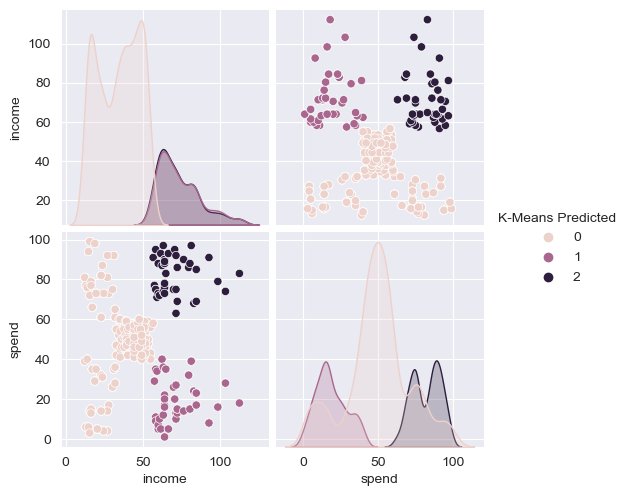

In [79]:
# Use three clusters k=3.
kmeans = KMeans(n_clusters=3, 
                max_iter=15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

df3['K-Means Predicted'] = clusters

# Plot the predicted clusters.
sns.pairplot(df3,
             hue='K-Means Predicted',
             diag_kind='kde')

In [80]:
# Check the number of observations per predicted class.
df3['K-Means Predicted'].value_counts()

K-Means Predicted
0    1293
2     356
1     351
Name: count, dtype: int64

In [81]:
# View the K-Means predicted.
print(df3.head())

   income  spend  K-Means Predicted
0   12.30     39                  0
1   12.30     81                  0
2   13.12      6                  0
3   13.12     77                  0
4   13.94     40                  0


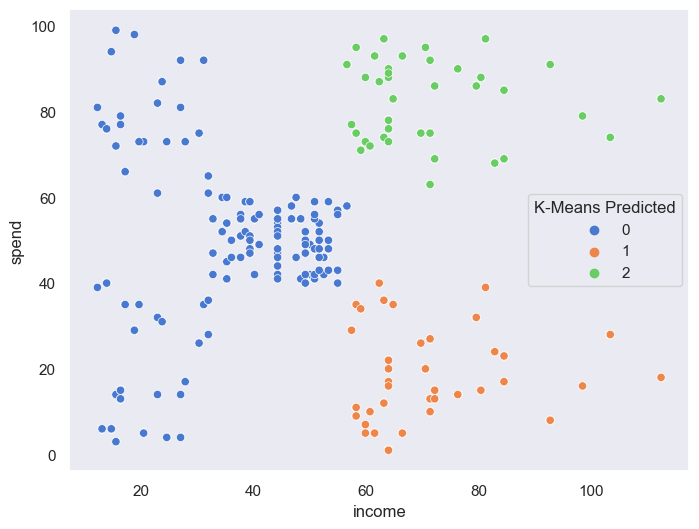

In [82]:
# Visualising the clusters.
# Set plot size.
sns.set(rc = {'figure.figsize':(8, 6)})

# Create a scatterplot.
sns.scatterplot(x='income' , 
                y ='spend',
                data=df3,
                hue='K-Means Predicted',
                palette='muted')
plt.grid(False)

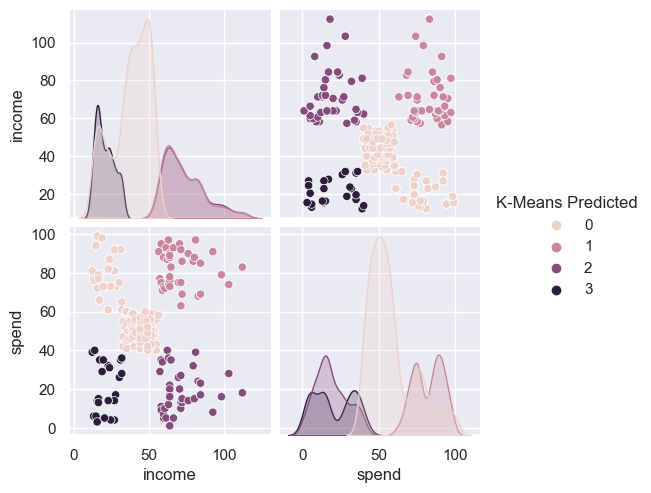

In [83]:
# Use three clusters k=4.
kmeans = KMeans(n_clusters=4, 
                max_iter=15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

df3['K-Means Predicted'] = clusters

# Plot the predicted clusters.
sns.pairplot(df3,
             hue='K-Means Predicted',
             diag_kind='kde')

In [84]:
# Check the number of observations per predicted class.
df3['K-Means Predicted'].value_counts()

K-Means Predicted
0    1013
1     356
2     351
3     280
Name: count, dtype: int64

In [85]:
# View the K-Means predicted.
print(df3.head())

   income  spend  K-Means Predicted
0   12.30     39                  3
1   12.30     81                  0
2   13.12      6                  3
3   13.12     77                  0
4   13.94     40                  3


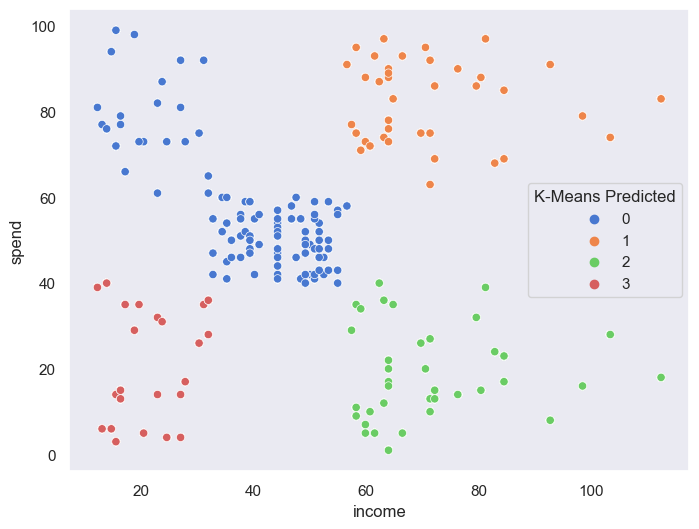

In [86]:
# Visualising the clusters.
# Set plot size.
sns.set(rc = {'figure.figsize':(8, 6)})

# Create a scatterplot.
sns.scatterplot(x='income' , 
                y ='spend',
                data=df3,
                hue='K-Means Predicted',
                palette='muted')
plt.grid(False)

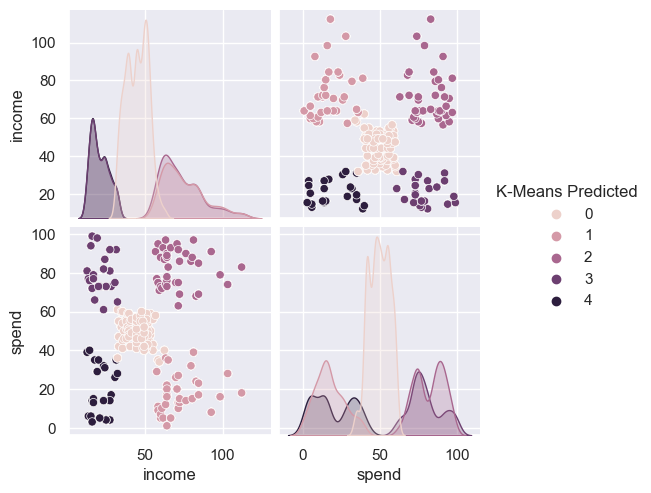

In [87]:
# Use three clusters k=5.
kmeans = KMeans(n_clusters=5, 
                max_iter=15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

df3['K-Means Predicted'] = clusters

# Plot the predicted clusters.
sns.pairplot(df3,
             hue='K-Means Predicted',
             diag_kind='kde')

In [88]:
# Check the number of observations per predicted class.
df3['K-Means Predicted'].value_counts()

K-Means Predicted
0    774
2    356
1    330
4    271
3    269
Name: count, dtype: int64

In [89]:
# View the K-Means predicted.
print(df3.head())

   income  spend  K-Means Predicted
0   12.30     39                  4
1   12.30     81                  3
2   13.12      6                  4
3   13.12     77                  3
4   13.94     40                  4


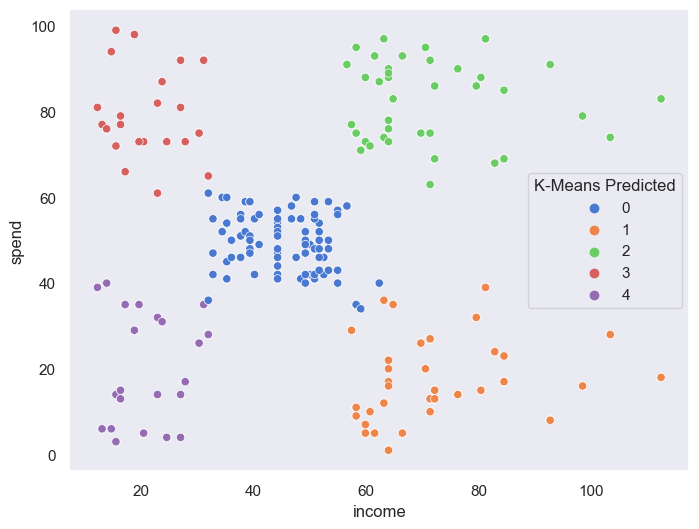

In [90]:
# Visualising the clusters.
# Set plot size.
sns.set(rc = {'figure.figsize':(8, 6)})

# Create a scatterplot.
sns.scatterplot(x='income' , 
                y ='spend',
                data=df3,
                hue='K-Means Predicted',
                palette='muted')
plt.grid(False)

## 5. Fit final model and justify your choice

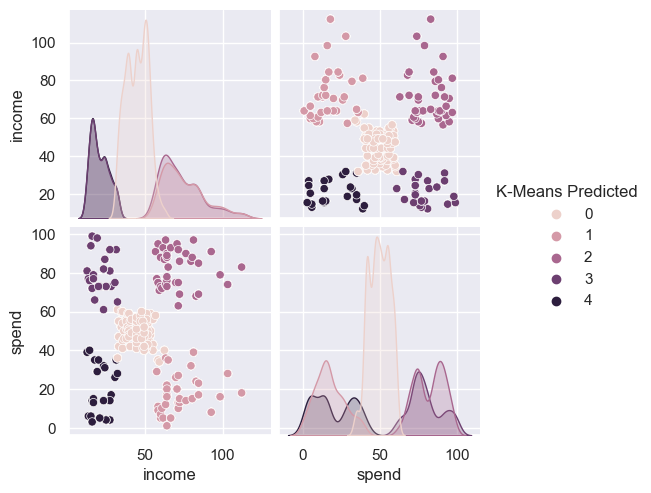

In [91]:
# Apply the final model.
# Use five clusters k=5.
kmeans = KMeans(n_clusters=5, 
                max_iter=15000,
                init='k-means++',
                random_state=0).fit(x)

clusters = kmeans.labels_

df3['K-Means Predicted'] = clusters

# Plot the predicted clusters.
sns.pairplot(df3,
             hue='K-Means Predicted',
             diag_kind='kde')

In [92]:
# Check the number of observations per predicted class.
df3['K-Means Predicted'].value_counts()

K-Means Predicted
0    774
2    356
1    330
4    271
3    269
Name: count, dtype: int64

## 6. Plot and interpret the clusters

In [93]:
# Visualising the clusters.
# View the DataFrame.
df3.head(10)

,income,spend,K-Means Predicted
0,12.30,39,4
1,12.30,81,3
2,13.12,6,4
3,13.12,77,3
4,13.94,40,4
5,13.94,76,3
6,14.76,6,4
7,14.76,94,3
8,15.58,3,4
9,15.58,72,3


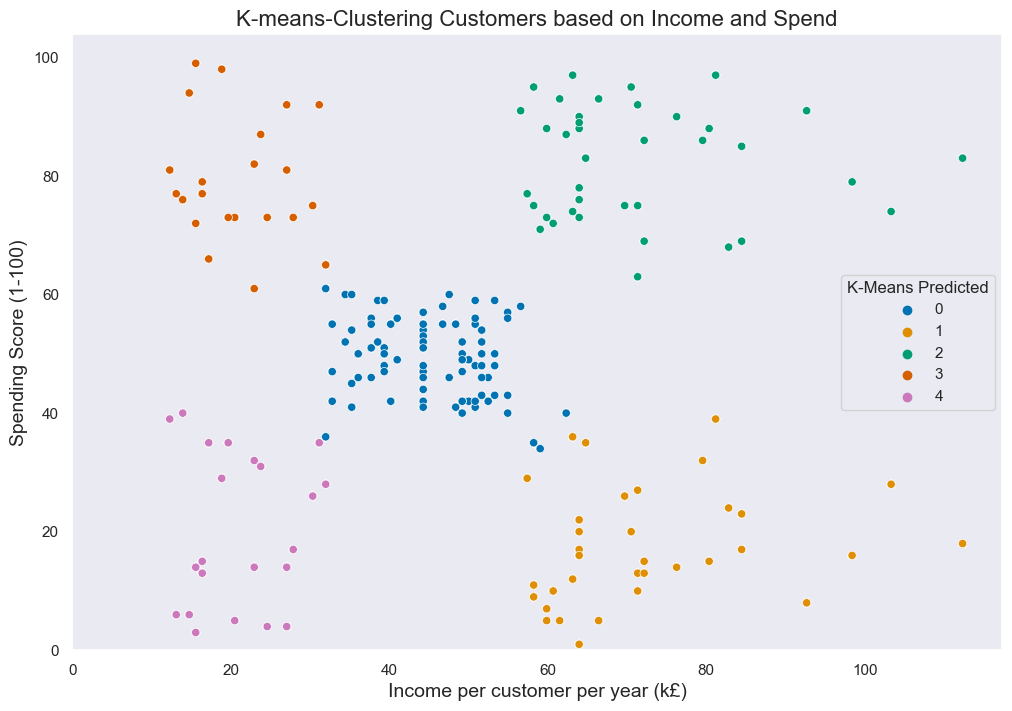

In [94]:
# Visualising the clusters.
# Set plot size.
plt.figure(figsize=(12, 8))

# Create a scatterplot.
sns.scatterplot(x='income' , 
                y ='spend',
                data=df3,
                hue='K-Means Predicted',
                palette='colorblind')\
                .set_title('K-means-Clustering Customers based on Income and Spend',
                          fontsize=16)

plt.xlim(0)
plt.ylim(0)
plt.xlabel('Income per customer per year (k£)', fontsize=14)
plt.ylabel('Spending Score (1-100)', fontsize=14)
plt.grid(False)
plt.savefig('kmeans_clusters.png');

## 7. Discuss: Insights and observations

- The initial scatterplot confirms the presence of hard clusters among the five classes.
- Observing clear separation among the data points, both the Elbow and Silhouette methods indicate that 5 is the optimal value for k in a k-means clustering model.
- This analysis enables businesses to segment customers based on income and spending patterns, facilitating targeted marketing campaigns, product development, and personalized customer interactions. By understanding distinct customer clusters, businesses can optimize resource allocation, enhance customer experiences, and capitalize on market opportunities for sustainable growth and competitiveness.

# Week 4 assignment: NLP using Python
Customer reviews were downloaded from the website of Turtle Games. This data will be used to steer the marketing department on how to approach future campaigns. 
Hence, it is essential to identify the 15 most frequent terms used in online product reviews and compile a roster of the top 20 positive and negative reviews garnered from the website by employing Natural Language Processing (NLP) techniques on the dataset.

**Can social data (e.g. customer reviews and summaries) be used in marketing campaigns?**

## 1. Load and explore the data

In [95]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt

# nltk.download ('punkt').
# nltk.download ('stopwords').

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [96]:
# Load the reviews data set with 'review' and 'summary' as df4.
df4 = reviews[['review', 'summary']]

# View DataFrame.
df4.head()

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [97]:
# Explore data set.
df4.shape

(2000, 2)

In [98]:
# Determine if there are any missing values.
df4.isnull().sum()

review     0
summary    0
dtype: int64

## 2. Prepare the data for NLP
### 2a) Change to lower case and join the elements in each of the columns respectively (review and summary)

In [99]:
# Review: Change all to lower case and join with a space.
df4['review'] = df4['review'].apply(lambda x: " ".join(x.lower() for x in x.split()))

# Preview the result.
df4['review'].head()

0    when it comes to a dm's screen, the space on t...
1    an open letter to galeforce9*: your unpainted ...
2    nice art, nice printing. why two panels are fi...
3    amazing buy! bought it as a gift for our new d...
4    as my review of gf9's previous screens these w...
Name: review, dtype: object

In [100]:
# Summary: Change all to lower case and join with a space.
df4['summary'] = df4['summary'].apply(lambda x: " ".join(x.lower() for x in x.split()))

# Preview the result.
df4['summary'].head()

0    the fact that 50% of this space is wasted on a...
1    another worthless dungeon master's screen from...
2                      pretty, but also pretty useless
3                                           five stars
4                                           money trap
Name: summary, dtype: object

### 2b) Replace punctuation in each of the columns respectively (review and summary)

In [101]:
import re

# Remove all the punctuations in review column.
df4['review'] = [re.sub('[^\w\s]+', '', s) for s in df4['review'].tolist()]

# Remove all the puncuations in summary column.
df4['summary'] = [re.sub('[^\w\s]+', '', s) for s in df4['summary'].tolist()]

# View output.
df4.head(10)

,review,summary
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...
2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gf9s previous screens these we...,money trap
5,grandson loves,five stars
6,i have bought many gm screens over the years b...,best gm screen ever
7,came in perfect condition,five stars
8,could be better but its still great i love the...,great but could be even better
9,my review will mirror others in that this kind...,another missed opportunity not a value add to ...


### 2c) Drop duplicates in both columns

In [102]:
# Check the number of duplicate values in the review column.
df4.review.duplicated().sum()

50

In [103]:
# Check the number of duplicate values in the summary column.
df4.summary.duplicated().sum()

649

In [104]:
# View duplicates in df4.
duplicates = df4[df4.duplicated(keep=False)]
duplicates.head(10)

,review,summary
43,i love it,five stars
48,love it,five stars
55,great,five stars
78,good product,five stars
94,great,five stars
294,good,five stars
326,love it,five stars
371,great,five stars
404,good,five stars
408,great,five stars


In [105]:
# Drop duplicates in both columns.
# df4.drop_duplicates(subset=['review'])
# df4.drop_duplicates(subset=['summary'])

# View DataFrame.
# df4.reset_index(inplace=True)
# df4.head()

- Despite the presence of 50 duplicates in the review column and 649 in the summary column, it has been determined not to remove them, given that they were authored by distinct customers.

## 3. Tokenise and create wordclouds

In [106]:
# Create new DataFrame (copy DataFrame).
df4 = df4.copy()

# View DataFrame.
df4.head()

,review,summary
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...
2,nice art nice printing why two panels are fill...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gf9s previous screens these we...,money trap


In [107]:
# Install the required tokenisation model.
nltk.download('punkt')

# Install the required tokenisation function.
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [108]:
# Apply tokenisation to both columns.
# Apply tokenization to 'review' column.
df4['review_tokens'] = df4['review'].apply(word_tokenize)

# Apply tokenization to 'summary' column.
df4['summary_tokens'] = df4['summary'].apply(word_tokenize)

# Wiew the dataFrame.
df4.head()

,review,summary,review_tokens,summary_tokens
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, 50, of, this, space, is, was..."
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, masters, screen,..."
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]"
3,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]"
4,as my review of gf9s previous screens these we...,money trap,"[as, my, review, of, gf9s, previous, screens, ...","[money, trap]"


In [109]:
# Convert list of tokens into a string variable.
# Define an empty list of tokens.
review_tokens_string = ''

# Iterate over each row in the DataFrame
for index, row in df4.iterrows():
    # Concatenate each token to the string
    review_tokens_string += ' '.join(row['review_tokens']) + ' '

print(review_tokens_string[:500])

when it comes to a dms screen the space on the screen itself is at an absolute premium the fact that 50 of this space is wasted on art and not terribly informative or needed art as well makes it completely useless the only reason that i gave it 2 stars and not 1 was that technically speaking it can at least still stand up to block your notes and dice rolls other than that it drops the ball completely an open letter to galeforce9 your unpainted miniatures are very not bad your spell cards are gre


In [110]:
# Set the colour palette.
sns.set(color_codes=True)

# Review: Create a word cloud.
wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma',
                stopwords = 'none',
                min_font_size = 10).generate(review_tokens_string)

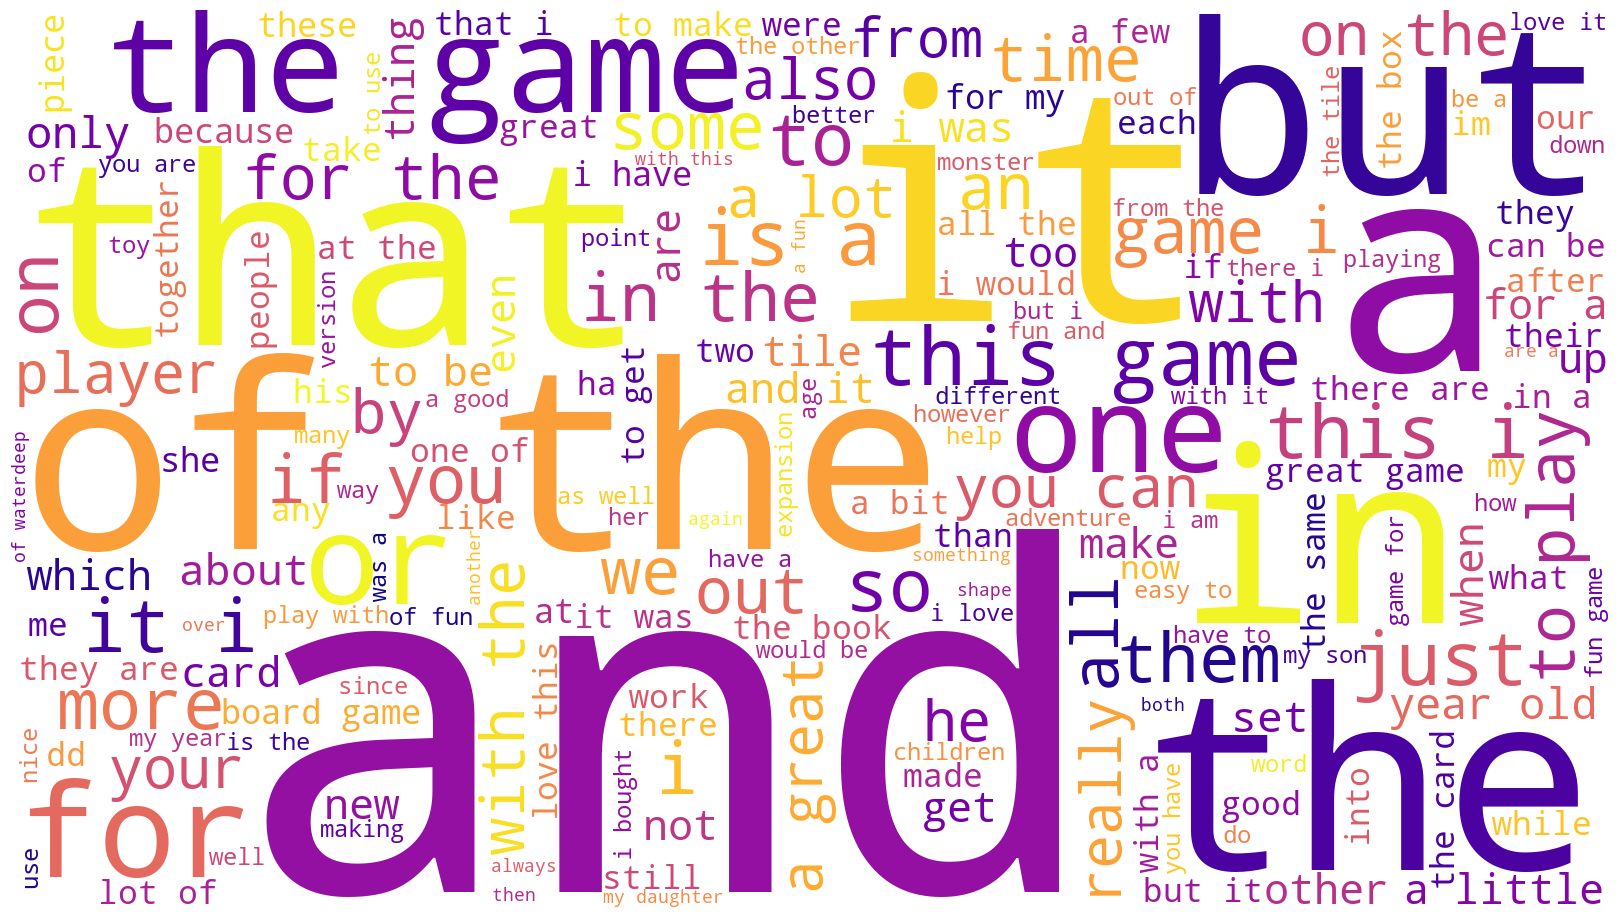

In [111]:
# Review: Plot the WordCloud image.                       
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

In [112]:
# Convert list of tokens into a string variable.
# Define an empty list of tokens.
summary_tokens_string = ''

# Iterate over each row in the DataFrame
for index, row in df4.iterrows():
    # Concatenate each token to the string
    summary_tokens_string += ' '.join(row['summary_tokens']) + ' '

print(summary_tokens_string[:500])

the fact that 50 of this space is wasted on art and not terribly informative or needed art another worthless dungeon masters screen from galeforce9 pretty but also pretty useless five stars money trap five stars best gm screen ever five stars great but could be even better another missed opportunity not a value add to the product line five stars love the map not a general dm screen very weak game fell completely flat five stars good book buckley was a card mommer very advanced but as good as it 


In [113]:
# Summary: Plot the WordCloud image.
wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma',
                stopwords = 'none',
                min_font_size = 10).generate(summary_tokens_string)

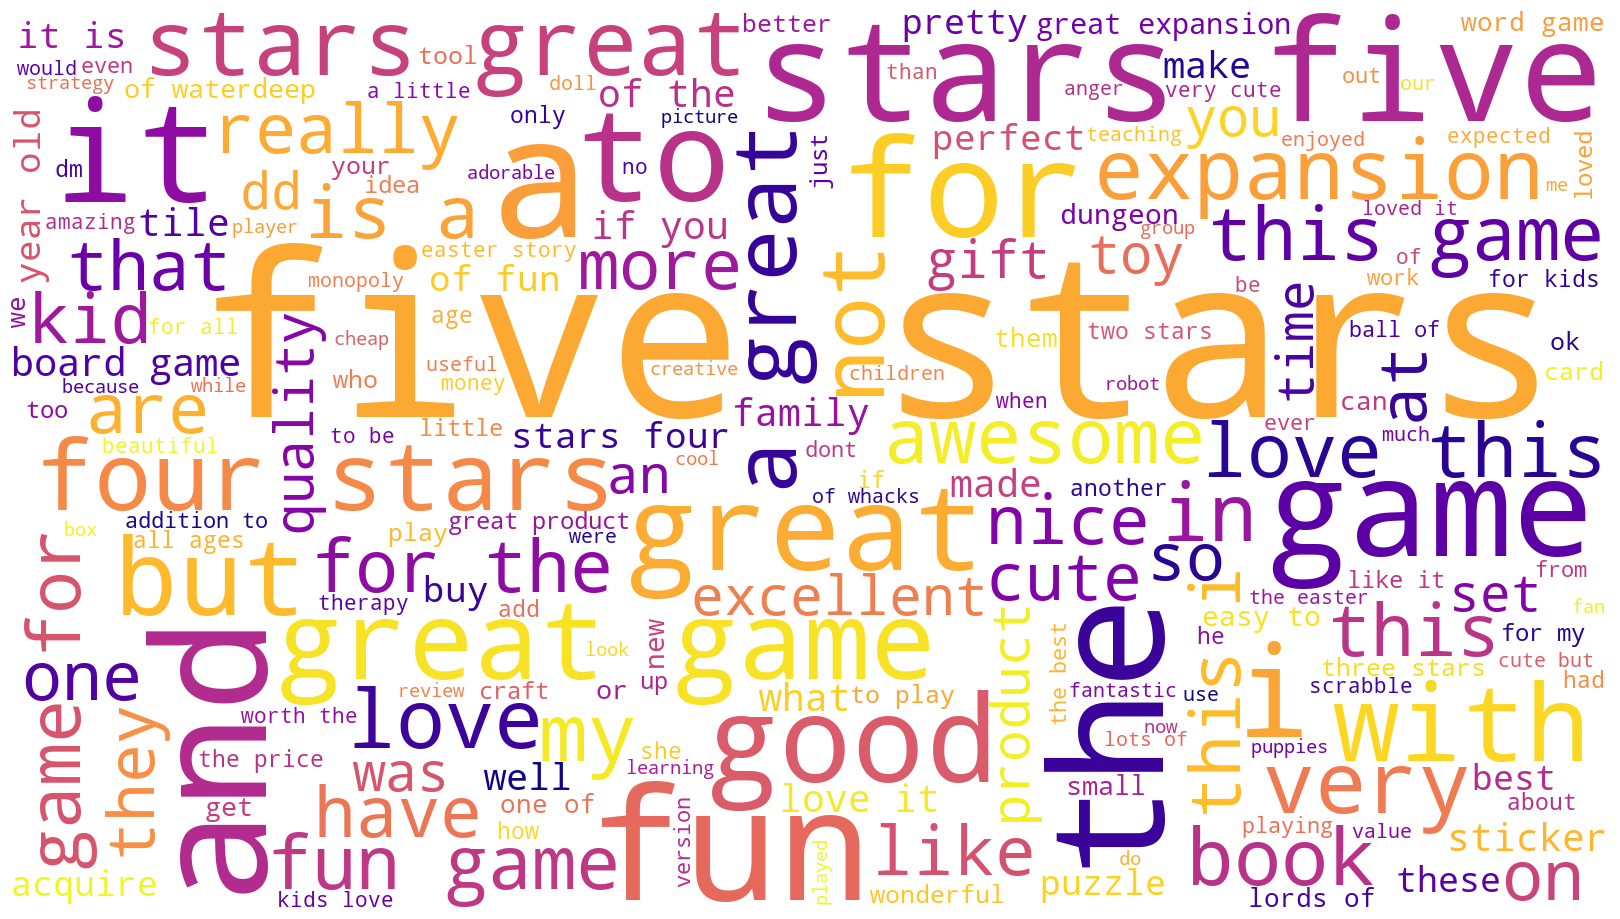

In [114]:
# Summary: Plot the WordCloud image.
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

- The next step is to introduce stopwords. These common words not fully capture the essence of customer reviews.

## 4. Frequency distribution and polarity
### 4a) Create frequency distribution

In [115]:
# Determine the frequency distribution for review tokens.
# Flatten the list of lists into a single list of tokens.
review_tokens = [token for sublist in df4['review_tokens'] for token in sublist]

# Import the FreqDist class.
from nltk.probability import FreqDist

# Calculate the frequency distribution.
fdist_review = FreqDist(review_tokens)

# Preview data.
fdist_review

FreqDist({'the': 5452, 'and': 3234, 'to': 3164, 'a': 3161, 'of': 2488, 'i': 2091, 'it': 2090, 'is': 1782, 'this': 1776, 'game': 1685, ...})

In [116]:
# Determine the frequency distribution for summary tokens.
# Flatten the list of lists into a single list of tokens.
summary_tokens = [token for sublist in df4['summary_tokens'] for token in sublist]

# Calculate the frequency distribution.
fdist_summary = FreqDist(summary_tokens)

# Preview data.
fdist_summary

FreqDist({'stars': 466, 'five': 381, 'game': 319, 'great': 295, 'the': 261, 'a': 240, 'for': 232, 'fun': 218, 'to': 192, 'and': 168, ...})

### 4b) Remove alphanumeric characters and stopwords

In [117]:
# Delete all the alpanum.
review_tokens = [word for word in review_tokens if word.isalnum()]

print("There are",len(review_tokens),"review tokens.")

There are 112194 review tokens.


In [118]:
# Delete all the alpanum.
summary_tokens = [word for word in summary_tokens if word.isalnum()]

print("There are",len(summary_tokens),"summary tokens.")

There are 9359 summary tokens.


In [119]:
# Download the stopword list.
nltk.download ('stopwords')
from nltk.corpus import stopwords

# Create a set of English stopwords.
english_stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [120]:
# Remove all the stopwords.
# Create a filtered list of review_tokens without stopwords.
review_no_sw = [x for x in review_tokens if x.lower() not in english_stopwords]

# Re-calculate the frequency distribution of review tokens without stopwords.
fdist_review2 = FreqDist(review_no_sw)

# Preview data.
fdist_review2

FreqDist({'game': 1685, 'great': 596, 'fun': 553, 'one': 530, 'play': 502, 'like': 414, 'love': 331, 'really': 319, 'get': 319, 'cards': 301, ...})

In [121]:
# Create a filtered list of summary_tokens without stopwords.
summary_no_sw = [x for x in summary_tokens if x.lower() not in english_stopwords]

# Re-calculate the frequency distribution of review tokens without stopwords.
fdist_summary2 = FreqDist(summary_no_sw)

# Preview data.
fdist_summary2

FreqDist({'stars': 466, 'five': 381, 'game': 319, 'great': 295, 'fun': 218, 'love': 93, 'good': 92, 'four': 58, 'like': 54, 'expansion': 52, ...})

### 4c) Create wordcloud without stopwords

In [122]:
# Define an empty string variable.
review_tokens_string = ''

for value in review_no_sw:
    # Add each filtered token word to the string.
    review_tokens_string = review_tokens_string + value + ' '

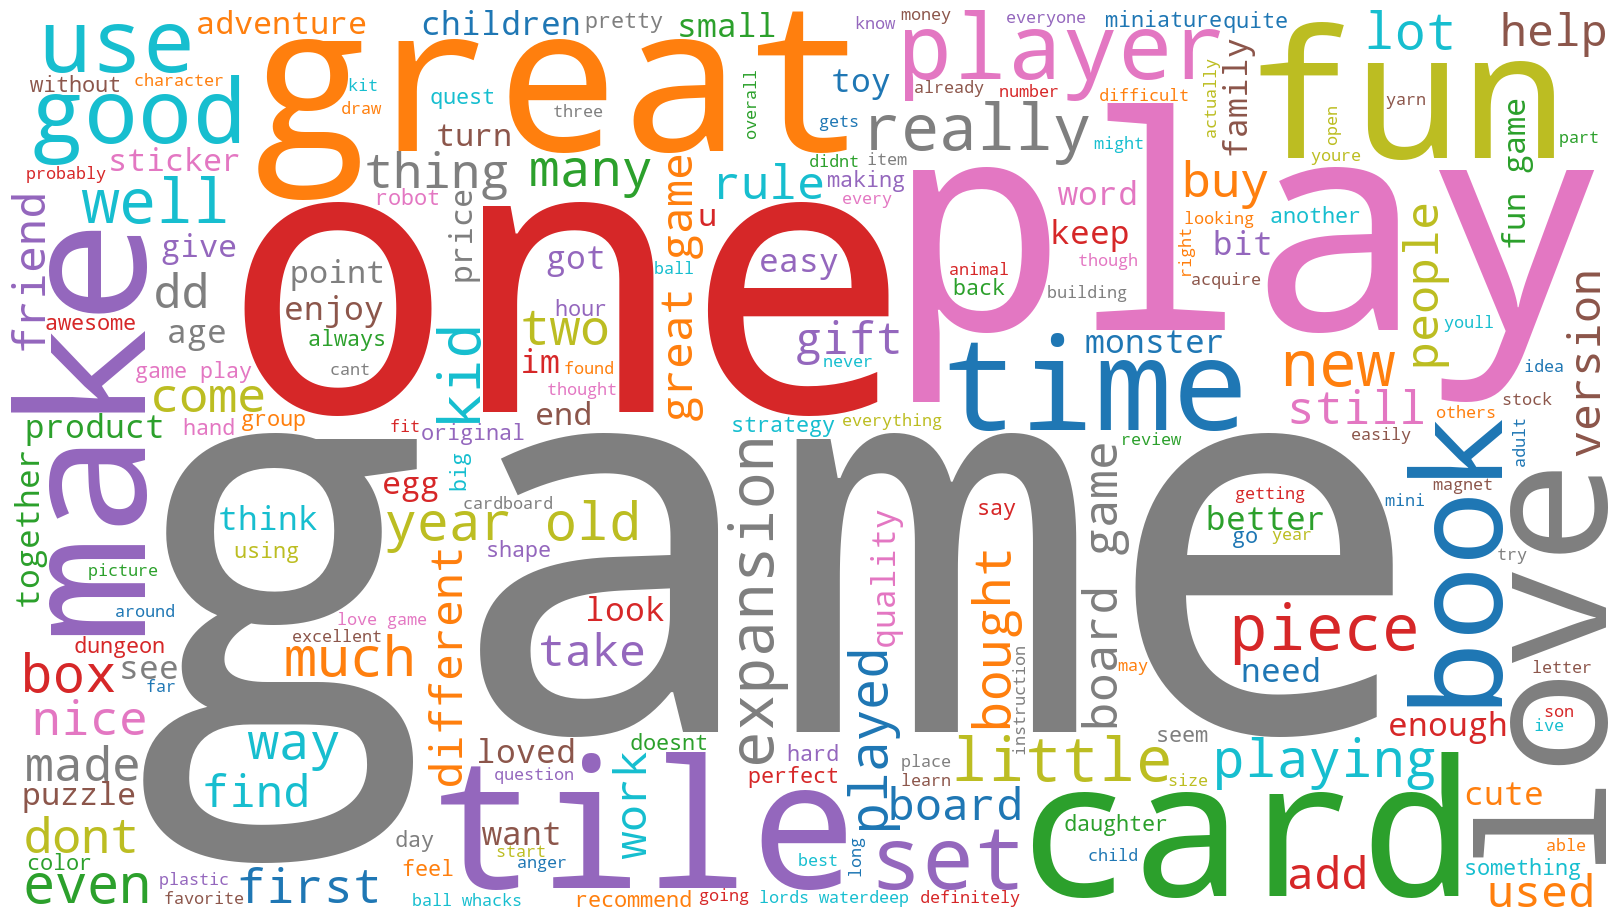

In [123]:
# Create a wordcloud without stop words.
# Review: Create a word cloud.
review_wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='tab10',
                min_font_size = 10).generate(review_tokens_string)

# Plot the WordCloud image from review.                        
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(review_wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 

plt.savefig('review_wordcloud')

In [124]:
# Convert list of tokens into a string variable.
# Define an empty string variable.
summary_tokens_string = ''

for value in summary_no_sw:
    # Add each filtered token word to the string.
    summary_tokens_string = summary_tokens_string + value + ' '

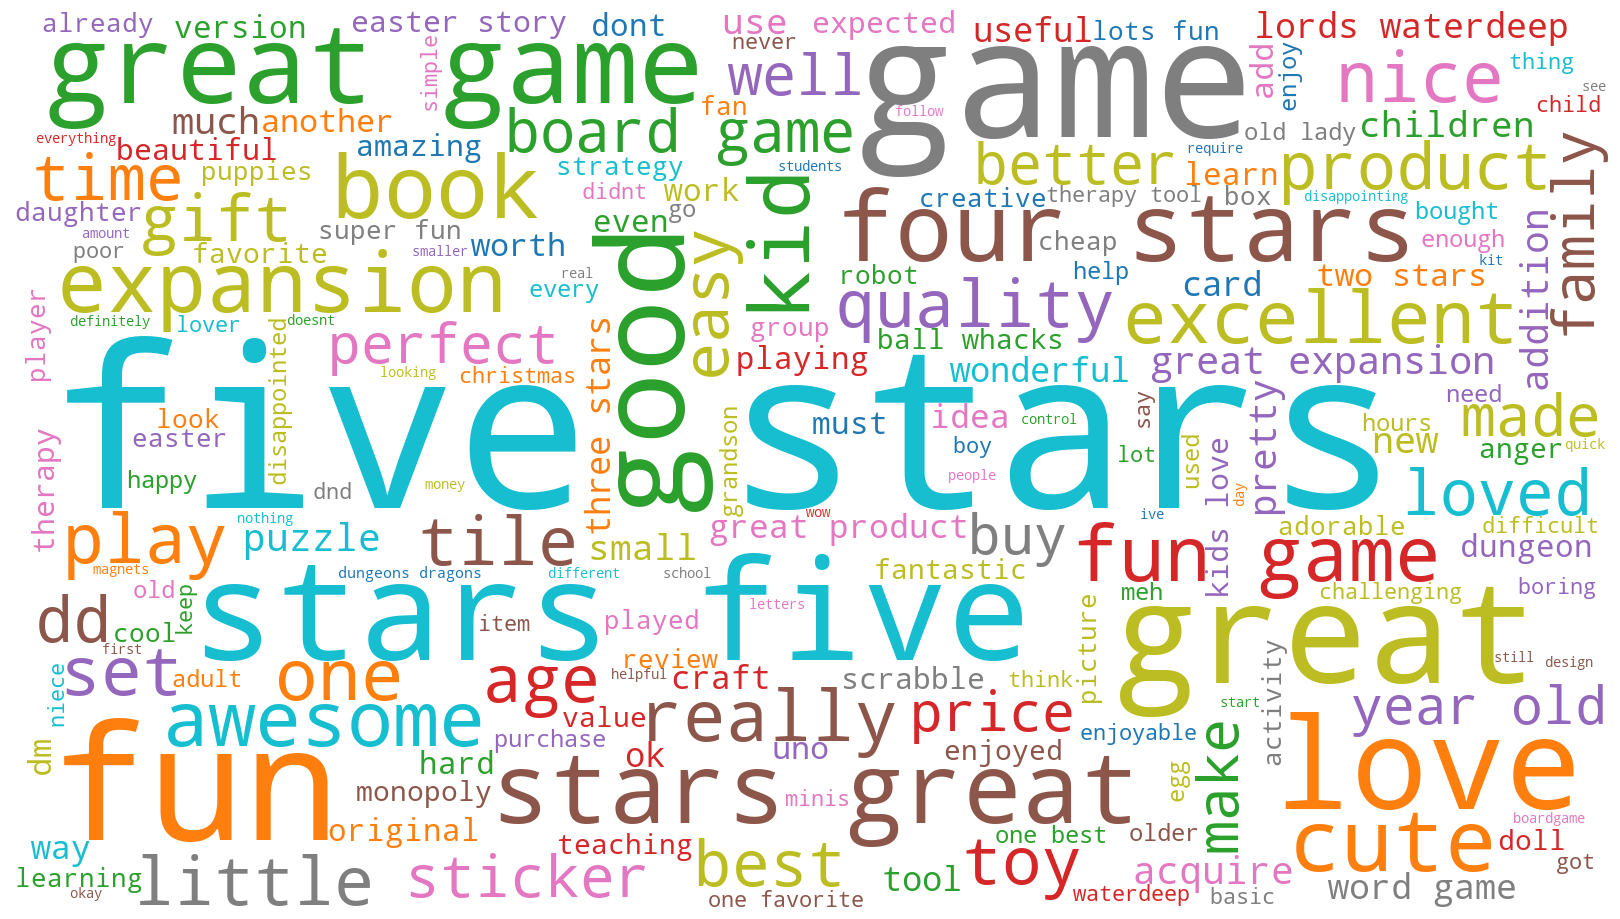

In [125]:
# Summary: Create a word cloud.
summary_wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='tab10',
                min_font_size = 10).generate(summary_tokens_string)

# Plot the WordCloud image from summary.                        
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(summary_wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 

plt.savefig('summary_wordcloud')

### 4d) Identify 15 most common words and polarity

In [126]:
# Determine the 15 most common words in review tokens without stopwords.
# Import the Counter class.
from collections import Counter

# Generate a DataFrame from Counter.
review_counts = pd.DataFrame(Counter(review_no_sw).most_common(15),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview data.
review_counts

,Frequency
Word,
game,1685
great,596
fun,553
one,530
play,502
like,414
love,331
really,319
get,319


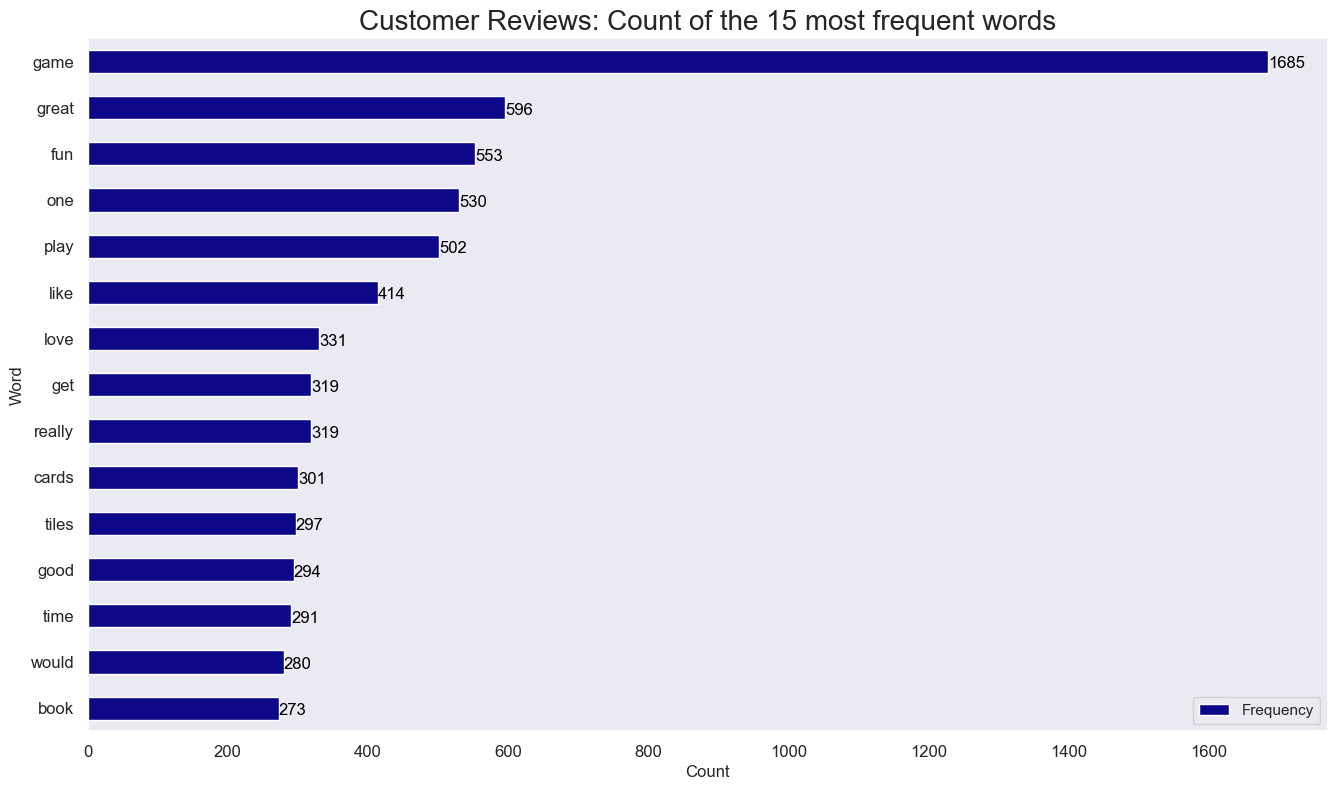

In [127]:
# Set the plot type.
# Sort the review_counts DataFrame by frequency in descending order.
review_counts_sorted = review_counts.sort_values(by='Frequency', ascending=True)

# Set the plot type.
ax = review_counts_sorted.plot(kind='barh', figsize=(16, 9), fontsize=12,
                               colormap='plasma')

# Set the labels.
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("Customer Reviews: Count of the 15 most frequent words",
             fontsize=20)
ax.grid(False)

# Draw the bar labels.
for i in ax.patches:
    ax.text(i.get_width() + 0.2, i.get_y() + 0.1,
            str(round((i.get_width()), 2)),
            fontsize=12, color='black')

In [128]:
# Determine the 15 most common words in summarytokens without stopwords.
summary_counts = pd.DataFrame(Counter(summary_no_sw).most_common(15),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview data.
summary_counts

,Frequency
Word,
stars,466
five,381
game,319
great,295
fun,218
love,93
good,92
four,58
like,54


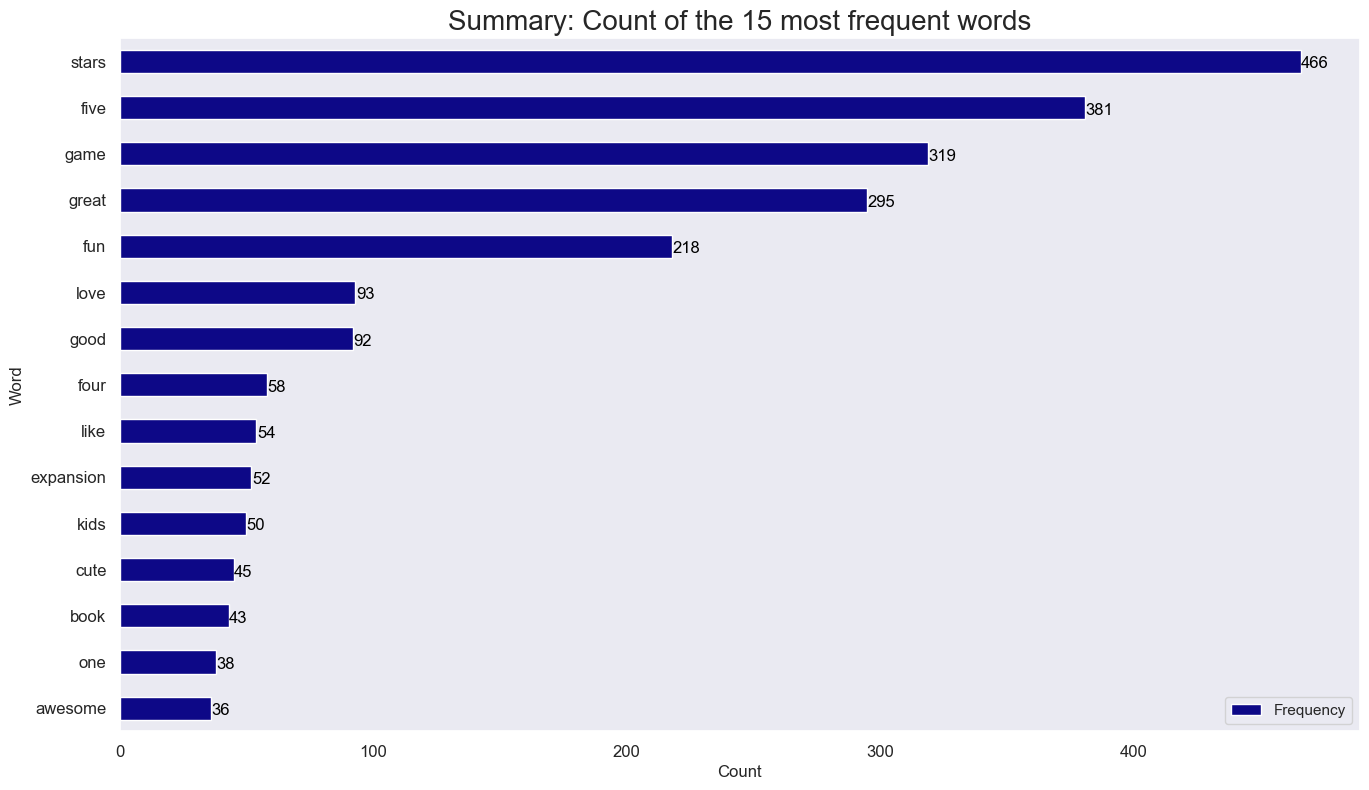

In [129]:
# Set the plot type.
# Sort the review_counts DataFrame by frequency in descending order.
summary_counts_sorted = summary_counts.sort_values(by='Frequency', ascending=True)

# Set the plot type.
ax = summary_counts_sorted.plot(kind='barh', figsize=(16, 9), fontsize=12,
                                colormap ='plasma')

# Set the labels.
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("Summary: Count of the 15 most frequent words",
             fontsize=20)
ax.grid(False)

# Draw the bar labels.
for i in ax.patches:
    ax.text(i.get_width() + 0.2, i.get_y() + 0.1,
            str(round((i.get_width()), 2)),
            fontsize=12, color='black')

- The consistent use of positive language in both the comprehensive reviews and the summaries indicates a strong favourability towards Turtle Game's products among customers. Notably, in the summary reviews, the frequent pairing of 'five' and 'stars' underscores the high level of satisfaction expressed by customers.

## 5. Review polarity and sentiment: Plot histograms of polarity (use 15 bins) and sentiment scores for the respective columns.

In [130]:
# Provided function.
def generate_polarity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[0]

In [131]:
# Determine polarity of both columns. 
df4['review_polarity'] = df4['review'].apply(generate_polarity)
df4['summary_polarity'] = df4['summary'].apply(generate_polarity)

# View output.
df4.head()

,review,summary,review_tokens,summary_tokens,review_polarity,summary_polarity
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, 50, of, this, space, is, was...",-0.036111,0.15
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, masters, screen,...",0.035952,-0.80
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]",0.116640,0.00
3,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]",0.578788,0.00
4,as my review of gf9s previous screens these we...,money trap,"[as, my, review, of, gf9s, previous, screens, ...","[money, trap]",-0.316667,0.00


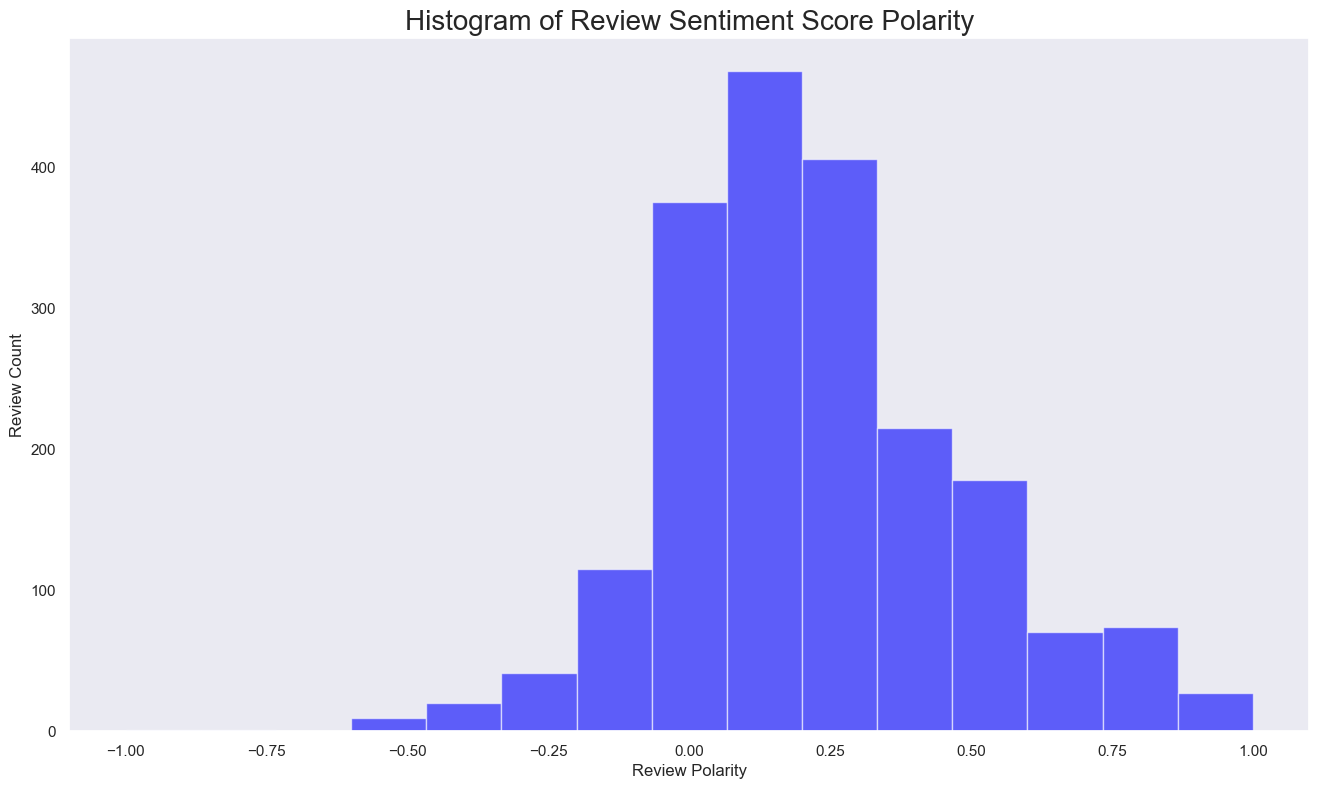

In [132]:
# Review: Create a histogram plot with bins = 15.
# Histogram of polarity sentiment score for reviews.
# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(df4['review_polarity'], num_bins, facecolor='blue', alpha=0.6)

# Set the labels.
plt.xlabel('Review Polarity', fontsize=12)
plt.ylabel('Review Count', fontsize=12)
plt.title('Histogram of Review Sentiment Score Polarity', fontsize=20)
plt.grid(False)

plt.show()

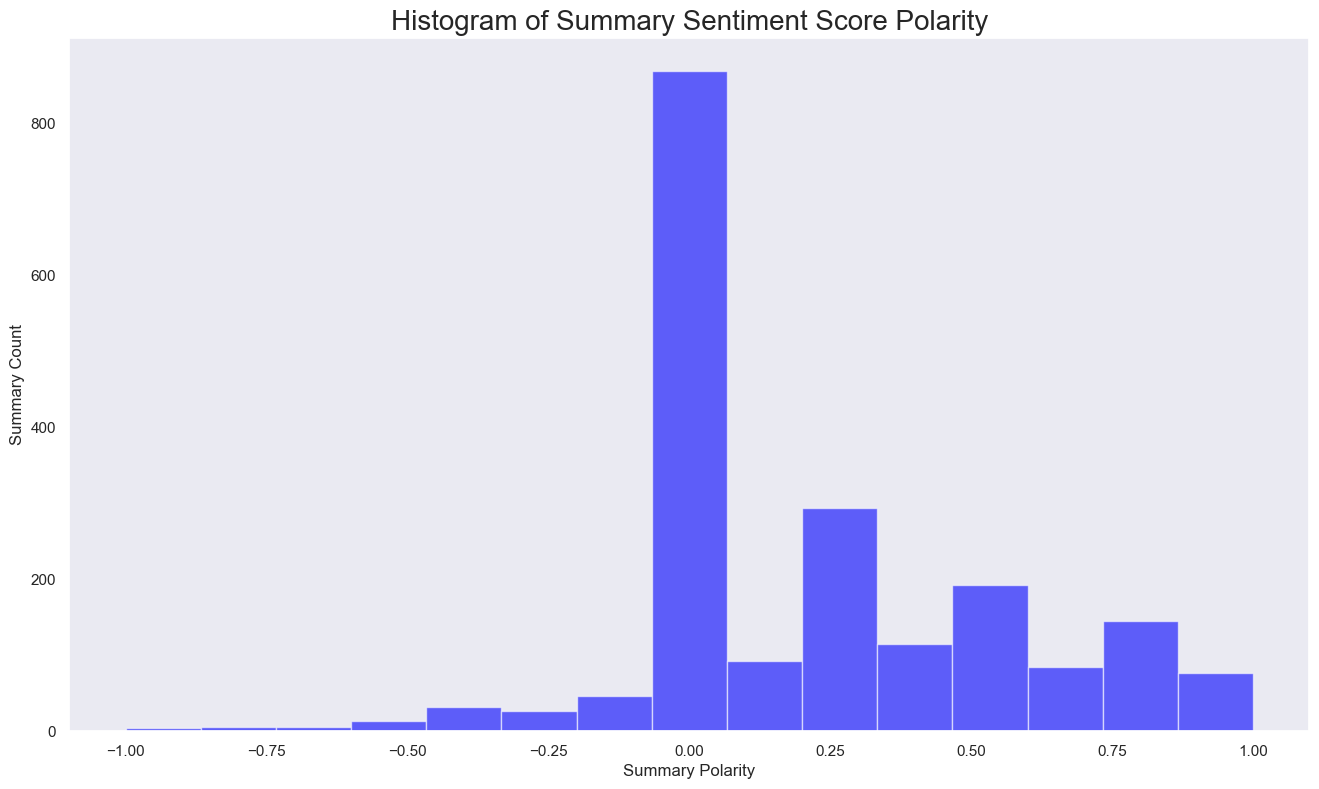

In [133]:
# Summary: Create a histogram plot with bins = 15.
# Histogram of polarity sentiment score for reviews.
# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(df4['summary_polarity'], num_bins, facecolor='blue', alpha=0.6)

# Set the labels.
plt.xlabel('Summary Polarity', fontsize=12)
plt.ylabel('Summary Count', fontsize=12)
plt.title('Histogram of Summary Sentiment Score Polarity', fontsize=20)
plt.grid(False)

plt.show()

In [134]:
# Subjectivity scores using TextBlob.
# Define a function to extract a polarity score for the comment.
def generate_subjectivity(comment):
    return TextBlob(comment).sentiment[1]

# Determine polarity of both columns. 
df4['review_subjectivity'] = df4['review'].apply(generate_subjectivity)
df4['summary_subjectivity'] = df4['summary'].apply(generate_subjectivity)

# View output.
df4.head()

,review,summary,review_tokens,summary_tokens,review_polarity,summary_polarity,review_subjectivity,summary_subjectivity
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, 50, of, this, space, is, was...",-0.036111,0.15,0.486111,0.500000
1,an open letter to galeforce9 your unpainted mi...,another worthless dungeon masters screen from ...,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, masters, screen,...",0.035952,-0.80,0.442976,0.900000
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]",0.116640,0.00,0.430435,0.733333
3,amazing buy bought it as a gift for our new dm...,five stars,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]",0.578788,0.00,0.784848,0.000000
4,as my review of gf9s previous screens these we...,money trap,"[as, my, review, of, gf9s, previous, screens, ...","[money, trap]",-0.316667,0.00,0.316667,0.000000


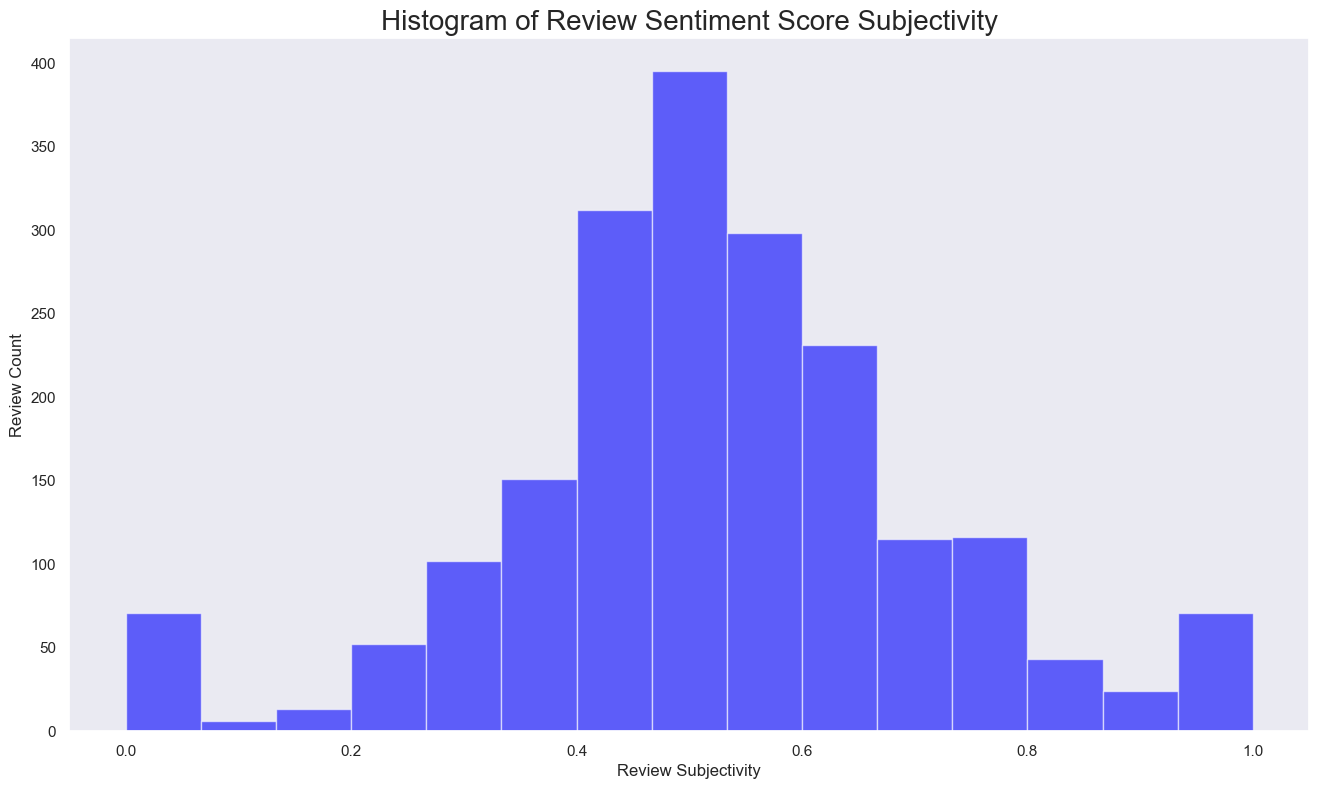

In [135]:
# Review: Create a histogram plot with bins = 15.
# Histogram of subjectivity score for reviews.
# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(df4['review_subjectivity'], num_bins, facecolor='blue', alpha=0.6)

# Set the labels.
plt.xlabel('Review Subjectivity', fontsize=12)
plt.ylabel('Review Count', fontsize=12)
plt.title('Histogram of Review Sentiment Score Subjectivity', fontsize=20)
plt.grid(False)

plt.show()

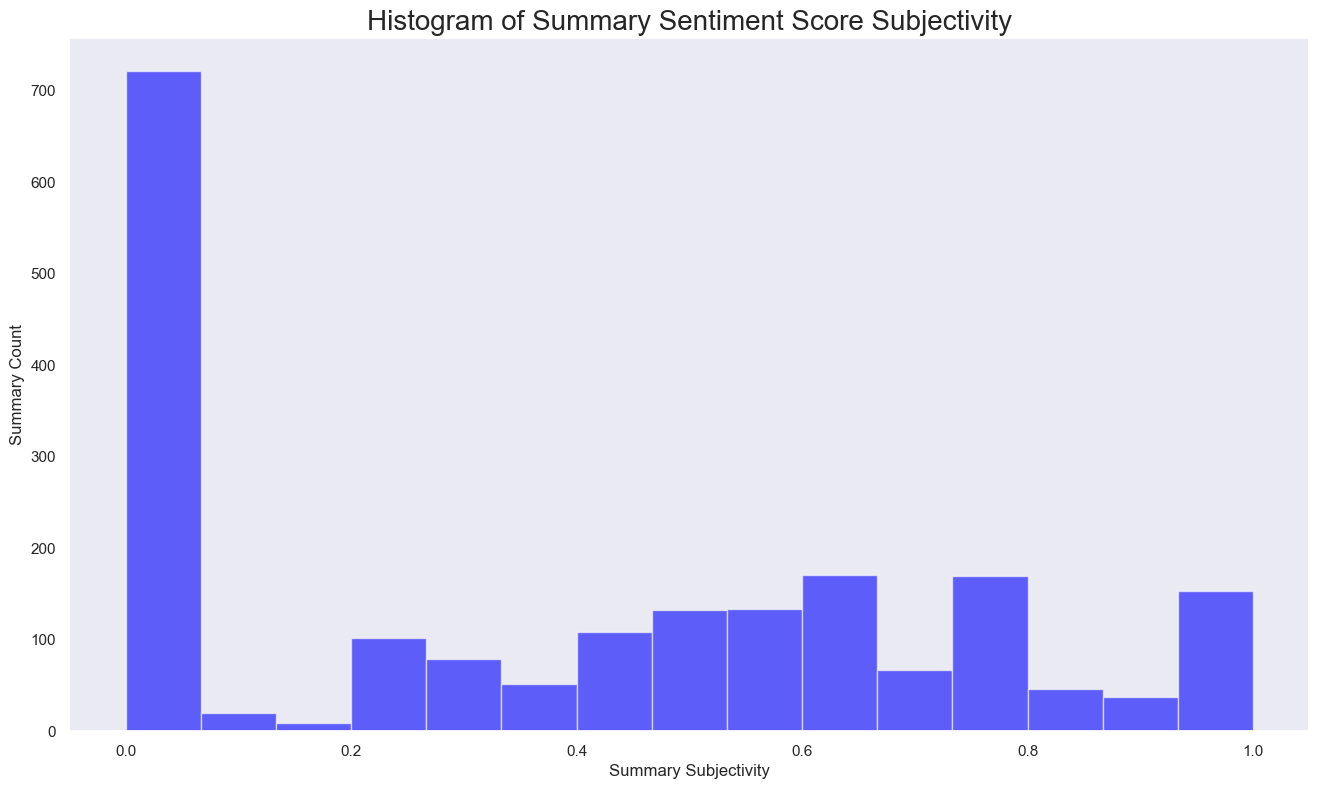

In [136]:
# Review: Create a histogram plot with bins = 15.
# Histogram of subjectivity score for summary.
# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16,9))

# Define the bars.
n, bins, patches = plt.hist(df4['summary_subjectivity'], num_bins, facecolor='blue', alpha=0.6)

# Set the labels.
plt.xlabel('Summary Subjectivity', fontsize=12)
plt.ylabel('Summary Count', fontsize=12)
plt.title('Histogram of Summary Sentiment Score Subjectivity', fontsize=20)
plt.grid(False)

plt.show()

- The polarity analysis conducted using text blob indicates that the majority of reviews and summaries convey a positive sentiment. However, it's important to note that the analysis doesn't accurately evaluate the phrase 'five stars', rating it as neutral instead of positive.

In [137]:
# Sentiment analysis using Vader.
df5 = reviews[['review', 'summary']]

# View DataFrame.
df5.head()

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [138]:
# Import the vader lexicon and vader class.
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Create a variable to store the sia.
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [139]:
# Calculate compound, positive, neutral, and negative scores for reviews.
df5['review_compound'] = [sia.polarity_scores(x)['compound'] for x in df5['review']]
df5['review_neg'] = [sia.polarity_scores(x)['neg'] for x in df5['review']]
df5['review_neutral'] = [sia.polarity_scores(x)['neu'] for x in df5['review']]
df5['review_pos'] = [sia.polarity_scores(x)['pos'] for x in df5['review']]

# Display the DataFrame.
df5[['review', 'review_compound', 'review_neg', 'review_neutral', 'review_pos']].head()

,review,review_compound,review_neg,review_neutral,review_pos
0,"When it comes to a DM's screen, the space on t...",-0.7406,0.109,0.856,0.035
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,0.9433,0.092,0.703,0.205
2,"Nice art, nice printing. Why two panels are f...",0.6939,0.122,0.723,0.155
3,Amazing buy! Bought it as a gift for our new d...,0.8997,0.000,0.477,0.523
4,As my review of GF9's previous screens these w...,-0.6808,0.203,0.797,0.000


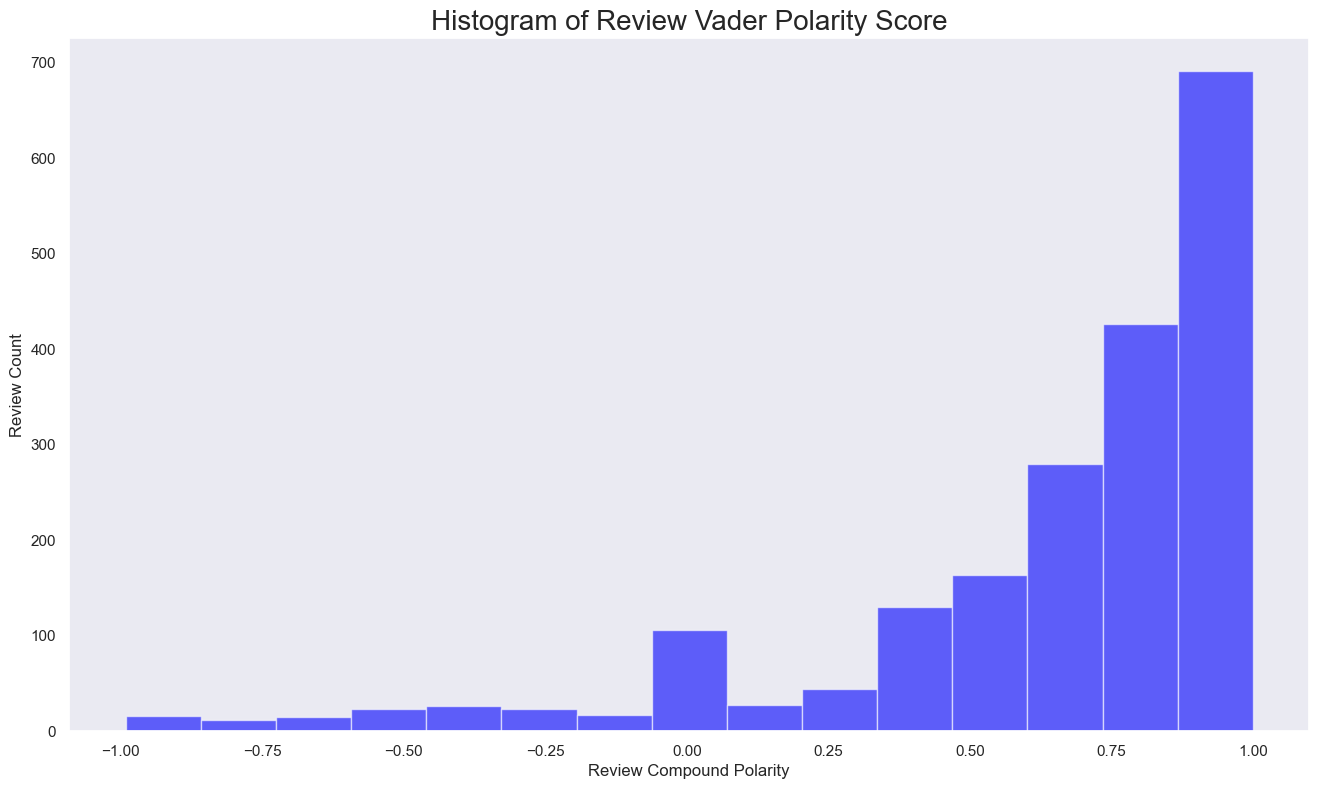

In [140]:
# Review: Create a histogram plot with bins = 15.
# Histogram of polarity sentiment score for reviews.
df4['review_compound'] = [sia.polarity_scores(x)['compound'] for x in df4['review']]

# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16, 9))

# Define the bars.
n, bins, patches = plt.hist(df4['review_compound'], num_bins, facecolor='blue', alpha=0.6)

# Set the labels.
plt.xlabel('Review Compound Polarity', fontsize=12)
plt.ylabel('Review Count', fontsize=12)
plt.title('Histogram of Review Vader Polarity Score', fontsize=20)
plt.grid(False)

plt.show()

In [141]:
# Calculate compound, positive, neutral, and negative scores for summaries.
df5['summary_compound'] = [sia.polarity_scores(x)['compound'] for x in df5['summary']]
df5['summary_neg'] = [sia.polarity_scores(x)['neg'] for x in df5['summary']]
df5['summary_neutral'] = [sia.polarity_scores(x)['neu'] for x in df5['summary']]
df5['summary_pos'] = [sia.polarity_scores(x)['pos'] for x in df5['summary']]

# View the output.
df5[['summary', 'summary_compound', 'summary_neg', 'summary_neutral', 'summary_pos']].head()

,summary,summary_compound,summary_neg,summary_neutral,summary_pos
0,The fact that 50% of this space is wasted on a...,-0.0711,0.138,0.735,0.126
1,Another worthless Dungeon Master's screen from...,-0.4404,0.326,0.674,0.000
2,"pretty, but also pretty useless",0.4019,0.306,0.165,0.529
3,Five Stars,0.0000,0.000,1.000,0.000
4,Money trap,-0.3182,0.697,0.303,0.000


- The Vader sentiment analysis also considers "Five Stars" as a neutral statement.

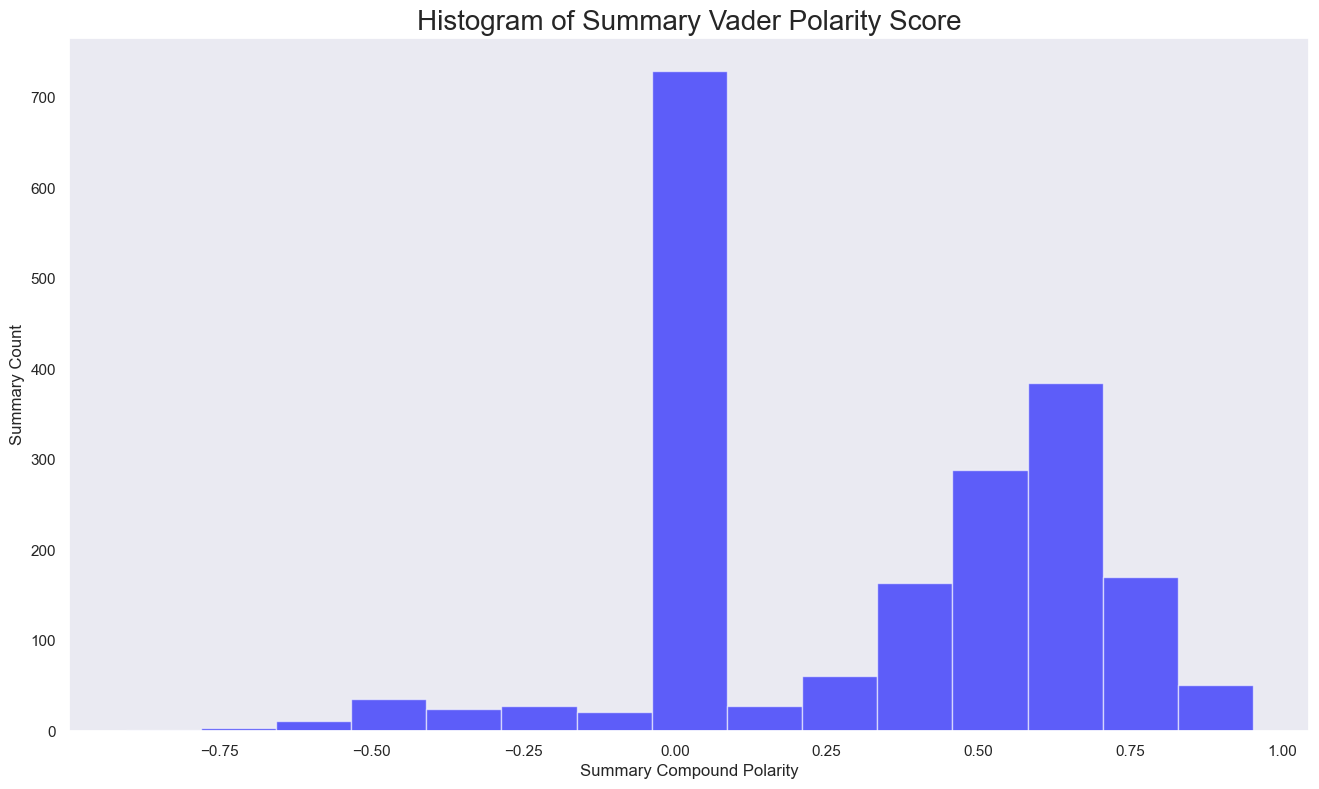

In [142]:
# Calculate sentiment scores for the 'summary' column
df4['summary_compound'] = [sia.polarity_scores(x)['compound'] for x in df4['summary']]

# Set the number of bins.
num_bins = 15

# Set the plot area.
plt.figure(figsize=(16, 9))

# Define the bars.
n, bins, patches = plt.hist(df4['summary_compound'], num_bins, facecolor='blue', alpha=0.6)

# Set the labels.
plt.xlabel('Summary Compound Polarity', fontsize=12)
plt.ylabel('Summary Count', fontsize=12)
plt.title('Histogram of Summary Vader Polarity Score', fontsize=20)
plt.grid(False)

plt.show()

- This underscores the limitations of sentiment analysis, including TextBlob and the Vader Sentiment Analysis, as phrases like 'five stars' might be perceived as positive by humans.

## 6. Identify top 20 positive and negative reviews and summaries respectively

In [143]:
# Top 20 negative reviews.
# Select top 20 negative reviews based on 'review_compound' column.
negative_reviews = df5.nsmallest(20, 'review_compound')

# Eliminate unnecessary columns.
negative_reviews = negative_reviews[['review', 'review_compound', 'summary', 'summary_compound']]

# Adjust the column width for better display.
negative_reviews_style = negative_reviews.style.set_properties(subset=['review'], **{'width': '1200px'})

# View the output.
negative_reviews_style

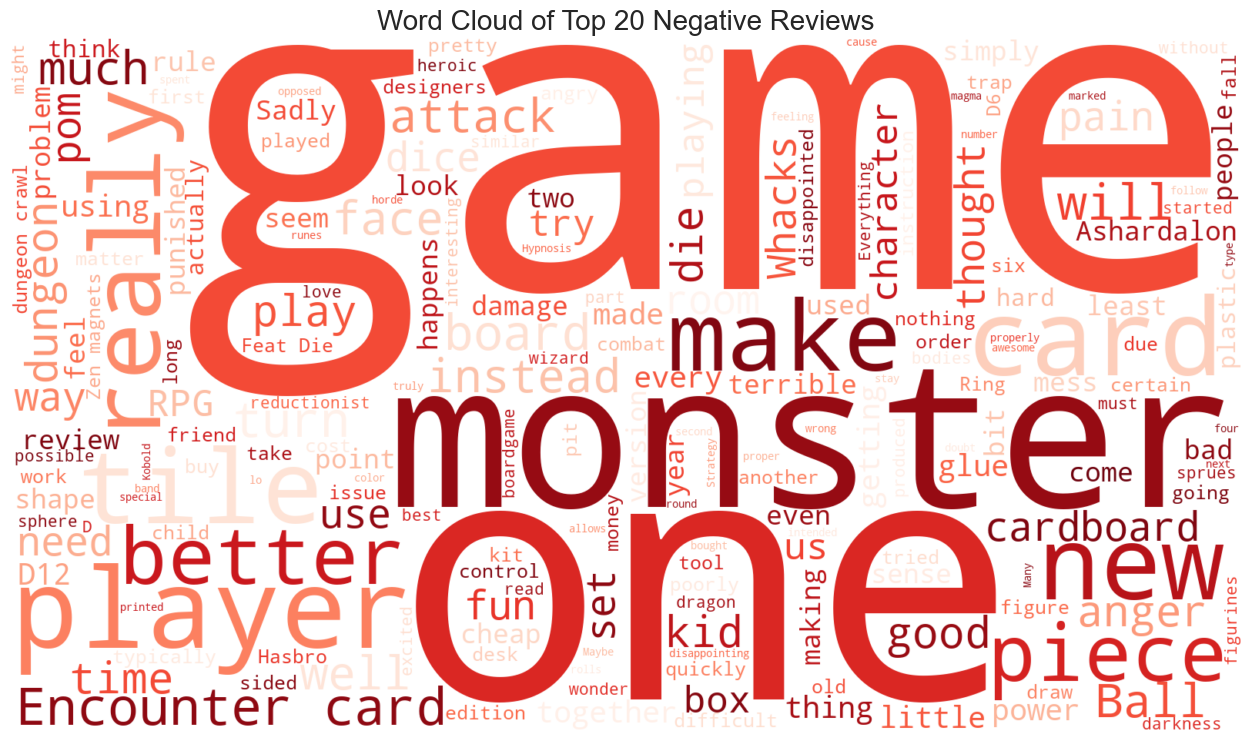

In [144]:
# Concatenate all negative reviews into a single string.
negative_reviews_text = ' '.join(negative_reviews['review'])

# Create a WordCloud object.
wordcloud = WordCloud(width=1600, height=900, background_color='white', colormap='Reds_r', min_font_size=10).generate(negative_reviews_text)

# Plot the WordCloud image.
plt.figure(figsize=(16, 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Top 20 Negative Reviews', fontsize=20)
plt.show()

In [145]:
# Top 20 negative summaries.
# Select top 20 negative reviews based on 'summary_compound' column.
negative_summaries = df5.nsmallest(20, 'summary_compound')

# Eliminate unnecessary columns.
negative_summaries = negative_summaries[['summary','summary_compound','review_compound']]

# Adjust the column width and view the output.
negative_summaries.style.set_properties(subset=['summary'], **{'width': '1200px'})

,summary,summary_compound,review_compound
882,"A crappy cardboard ghost of the original. Hard to believe they did this, but they did. Shame on Hasbro. Disgusting.",-0.905200,-0.905200
1565,"The TARDIS, The Doctor, River Song, Amy, Rory Fight Every Enemy - In Cards!",-0.750000,0.966100
947,No 20 sided die,-0.726900,0.000000
328,Defective- poor QC,-0.718400,0.976500
1003,Then you will find this board game to be dumb and boring,-0.680800,-0.493900
1166,before this I hated running any RPG campaign dealing with towns because it ...,-0.636900,-0.726900
426,but it gets repetitive and the students start to get bored after about half a round,-0.631000,-0.812600
847,Worst quality adult board game I've even seen,-0.624900,0.058300
173,Horrible! Nothing more to say Would give zero stars ...,-0.584800,-0.584800
364,Anger Control game,-0.571900,-0.413100


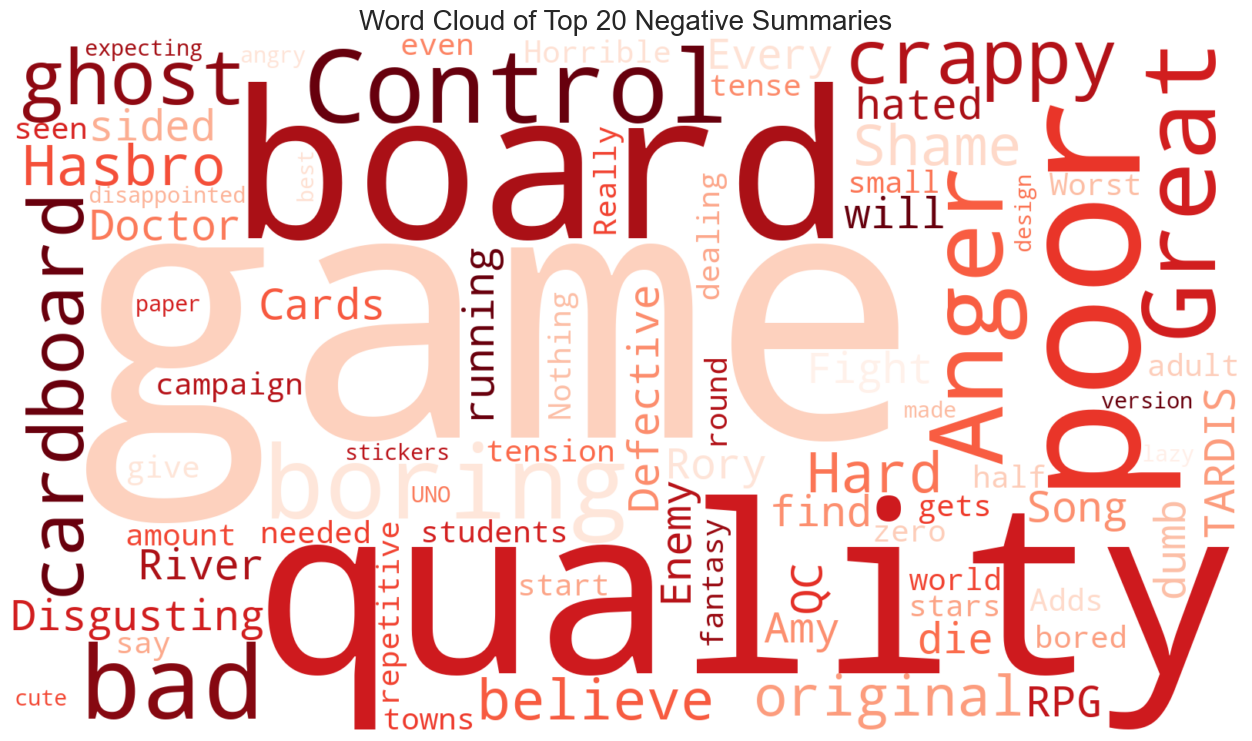

In [146]:
# Concatenate all summaries into a single string.
negative_summaries_text = " ".join(summary for summary in negative_summaries['summary'])

# Create the WordCloud object.
wordcloud = WordCloud(width=1600, height=900, background_color='white', colormap='Reds_r', min_font_size=10).generate(negative_summaries_text)

# Plot the WordCloud image.
plt.figure(figsize=(16, 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Top 20 Negative Summaries', fontsize=20)
plt.show()

- Analyzing negative reviews can offer valuable insights for Turtle Games, pinpointing areas for potential product improvement. The frequent mention of 'Quality and 'Poor' in these reviews underscores the importance of reassessing Turtle Games' product quality assurance procedures.

In [147]:
# Top 20 positive reviews.
positive_reviews = df5.nlargest(20, 'review_compound')

# Eliminate unnecessary columns.
positive_reviews = positive_reviews[['review', 'review_compound', 'summary', 'summary_compound']]

# Adjust the column width.
positive_reviews.style.set_properties(subset=['review'], **{'width': '1200px'})

In [148]:
# Top 20 positive summaries.
positive_summaries = df4.nlargest(20, 'summary_compound')

# Eliminate unnecessary columns.
positive_summaries = positive_summaries[['summary','summary_compound','review_compound']]

# Adjust the column width.
positive_summaries.style.set_properties(subset=['summary'], **{'width': '1200px'})

,summary,summary_compound,review_compound
1201,wow what a great set of tiles for such a great price a great starter set,0.952400,0.956000
1121,wrath of ashardalon great investment for an avid rpg fan who enjoys tabletop as well as crpgs,0.918600,0.999600
1699,great for playing great for creative workshops too,0.916900,0.969400
1955,easy to learn great fun to play,0.913600,0.790600
1543,loves stickers and she loves peppa so this was perfect,0.907400,0.936700
703,great quality very cute and perfect for my toddler,0.907300,0.907300
491,but the kids really like it and helps start good discussion,0.898800,0.898800
1029,great game great value,0.891000,0.992800
1189,great game value for the price is great also,0.891000,0.967700
973,i wish all those who buy better luck fairly easy to understand and plenty of,0.888500,0.800000


## 7. Discuss: Insights and observations

- Both TextBlob and Vader sentiment analyses predominantly classify Turtle Game reviews and summaries as positive, providing reassuring feedback.  An inherent limitation with both analyses is the interpretation of the phrase 'Five Stars' in summary reviews as neutral, despite its undoubtedly positive sentiment.

- Analysing negative reviews provides valuable insights for Turtle Games, identifying areas for potential product enhancement. The recurrent mention of 'Quality' in these reviews emphasizes the need for Turtle Games to reassess their product quality assurance protocols.
